# **Install & Import Libraries**

In [6]:
pip install paddleocr

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install paddlepaddle

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import json
import re
import random
from sklearn.model_selection import train_test_split
from collections import defaultdict

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForTokenClassification, Trainer, TrainingArguments, DataCollatorForTokenClassification
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# **Preprocessing**

In [9]:
"""
UPDATED AND CORRECTED PREPROCESSING
FULL MIMIC-III + MTSAMPLES

Main outputs:
    /kaggle/working/combined_medical_reports.csv
    /kaggle/working/train_reports.csv
    /kaggle/working/val_reports.csv
    /kaggle/working/test_reports.csv

    /kaggle/working/train_reports.jsonl
    /kaggle/working/val_reports.jsonl
    /kaggle/working/test_reports.jsonl

    /kaggle/working/dataset_info.json
"""

# ================================================================
# 0. IMPORTS
# ================================================================

import os
import re
import json
import math
import random
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


warnings.filterwarnings("ignore")


# ================================================================
# 1. REPRODUCIBILITY
# ================================================================

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


print("=" * 90)
print("CORRECTED PREPROCESSING - FULL MIMIC-III + MTSAMPLES")
print("=" * 90)


# ================================================================
# 2. FILE PATHS
# ================================================================

MTSAMPLES_PATH = (
    "/kaggle/input/datasets/tboyle10/"
    "medicaltranscriptions/mtsamples.csv"
)

LABEVENTS_PATH = (
    "/kaggle/input/datasets/samtajainj/labevents2-csv/LABEVENTS.csv"
)

PATIENTS_PATH = (
    "/kaggle/input/datasets/samtajainj/patients2/PATIENTS.csv"
)

D_LABITEMS_PATH = (
    "/kaggle/input/datasets/samtajainj/d-labitems2/D_LABITEMS.csv"
)

OUTPUT_DIR = "/kaggle/working"


# Number of synthetic MIMIC reports to generate
TARGET_MIMIC_REPORTS = 20000

# Maximum number of MIMIC patients to use
MAX_MIMIC_PATIENTS = None


# ================================================================
# 3. OUTPUT PATHS
# ================================================================

COMBINED_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "combined_medical_reports.csv"
)

TRAIN_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "train_reports.csv"
)

VAL_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "val_reports.csv"
)

TEST_CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "test_reports.csv"
)

TRAIN_JSONL_PATH = os.path.join(
    OUTPUT_DIR,
    "train_reports.jsonl"
)

VAL_JSONL_PATH = os.path.join(
    OUTPUT_DIR,
    "val_reports.jsonl"
)

TEST_JSONL_PATH = os.path.join(
    OUTPUT_DIR,
    "test_reports.jsonl"
)

DATASET_INFO_PATH = os.path.join(
    OUTPUT_DIR,
    "dataset_info.json"
)


# ================================================================
# 4. PATH VALIDATION
# ================================================================

def validate_file_path(path, description):
    """
    Confirm that a required dataset file exists.
    """

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"\nRequired file not found: {description}\n"
            f"Expected path:\n{path}\n"
        )

    print(f"  ✅ {description}: {path}")


print("\n📂 Validating dataset paths...")

validate_file_path(
    MTSAMPLES_PATH,
    "MTSamples"
)

validate_file_path(
    LABEVENTS_PATH,
    "MIMIC-III LABEVENTS"
)

validate_file_path(
    PATIENTS_PATH,
    "MIMIC-III PATIENTS"
)

validate_file_path(
    D_LABITEMS_PATH,
    "MIMIC-III D_LABITEMS"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ================================================================
# 5. HELPER FUNCTIONS
# ================================================================

def clean_column_names(df):
    """
    Convert DataFrame column names to lowercase without spaces.
    """

    df = df.copy()

    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
    )

    return df


def normalise_space(value):
    """
    Remove duplicate whitespace.
    """

    if value is None:
        return ""

    value = str(value)

    return re.sub(
        r"\s+",
        " ",
        value
    ).strip()


def safe_string(value):
    """
    Convert missing values into an empty string.
    """

    if value is None:
        return ""

    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass

    return normalise_space(value)


def python_scalar(value):
    """
    Convert NumPy values into JSON-serialisable Python values.
    """

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        return float(value)

    if isinstance(value, np.bool_):
        return bool(value)

    return value


def format_numeric_value(value):
    """
    Format a numeric laboratory result without unnecessary zeros.

    Examples:
        8.0      -> 8
        8.40     -> 8.4
        0.005    -> 0.005
    """

    try:
        value = float(value)
    except (TypeError, ValueError):
        return safe_string(value)

    if not np.isfinite(value):
        return ""

    if value.is_integer():
        return str(int(value))

    formatted = f"{value:.4f}"

    formatted = formatted.rstrip("0").rstrip(".")

    return formatted


def normalise_unit(unit):
    """
    Standardise common unit variants while preserving valid units.
    """

    unit = safe_string(unit)

    if not unit:
        return ""

    replacements = {
        "mg/dl": "mg/dL",
        "g/dl": "g/dL",
        "mmol/l": "mmol/L",
        "meq/l": "mEq/L",
        "iu/l": "IU/L",
        "u/l": "U/L",
        "miu/l": "mIU/L",
        "uiu/ml": "uIU/mL",
        "μiu/ml": "uIU/mL",
        "µiu/ml": "uIU/mL",
        "ug/ml": "ug/mL",
        "µg/ml": "ug/mL",
        "μg/ml": "ug/mL",
        "ug/dl": "ug/dL",
        "µg/dl": "ug/dL",
        "μg/dl": "ug/dL",
        "ng/ml": "ng/mL",
        "ng/dl": "ng/dL",
        "pg/ml": "pg/mL",
        "mosm/l": "mOsm/L",
        "mosm/kg": "mOsm/kg",
        "k/ul": "K/uL",
        "k/µl": "K/uL",
        "k/μl": "K/uL",
        "m/ul": "M/uL",
        "m/µl": "M/uL",
        "m/μl": "M/uL",
        "seconds": "sec",
        "second": "sec",
        "secs": "sec",
    }

    lower_unit = unit.lower()

    if lower_unit in replacements:
        return replacements[lower_unit]

    return unit


def normalise_test_name(test_name):
    """
    Clean a MIMIC laboratory test name.
    """

    test_name = safe_string(test_name)

    test_name = re.sub(
        r"\s+",
        " ",
        test_name
    ).strip()

    return test_name


def make_reference_text(low, high):
    """
    Create reference-range text.
    """

    if low is None or high is None:
        return ""

    return (
        f"{format_numeric_value(low)}-"
        f"{format_numeric_value(high)}"
    )


# ================================================================
# 6. REFERENCE-RANGE CONFIGURATION
# ================================================================

REFERENCE_RANGES = {
    "HEMOGLOBIN": {
        "aliases": [
            "hemoglobin",
            "haemoglobin",
            "hgb",
            "hb"
        ],
        "low": 12.0,
        "high": 16.0,
        "unit": "g/dL"
    },

    "HEMATOCRIT": {
        "aliases": [
            "hematocrit",
            "haematocrit",
            "hct"
        ],
        "low": 36.0,
        "high": 48.0,
        "unit": "%"
    },

    "PLATELETS": {
        "aliases": [
            "platelet count",
            "platelets",
            "platelet",
            "plt"
        ],
        "low": 150,
        "high": 450,
        "unit": "K/uL"
    },

    "WBC": {
        "aliases": [
            "white blood cell count",
            "white blood cells",
            "white blood cell",
            "wbc count",
            "wbc"
        ],
        "low": 4.5,
        "high": 11.0,
        "unit": "K/uL"
    },

    "RBC": {
        "aliases": [
            "red blood cell count",
            "red blood cells",
            "red blood cell",
            "rbc count",
            "rbc"
        ],
        "low": 4.0,
        "high": 5.5,
        "unit": "M/uL"
    },

    "CREATININE": {
        "aliases": [
            "creatinine"
        ],
        "low": 0.6,
        "high": 1.3,
        "unit": "mg/dL"
    },

    "GLUCOSE": {
        "aliases": [
            "glucose"
        ],
        "low": 70,
        "high": 100,
        "unit": "mg/dL"
    },

    "POTASSIUM": {
        "aliases": [
            "potassium"
        ],
        "low": 3.5,
        "high": 5.0,
        "unit": "mEq/L"
    },

    "SODIUM": {
        "aliases": [
            "sodium"
        ],
        "low": 135,
        "high": 145,
        "unit": "mEq/L"
    },

    "CHLORIDE": {
        "aliases": [
            "chloride"
        ],
        "low": 98,
        "high": 106,
        "unit": "mEq/L"
    },

    "BICARBONATE": {
        "aliases": [
            "bicarbonate",
            "total co2",
            "carbon dioxide",
            "co2"
        ],
        "low": 22,
        "high": 29,
        "unit": "mEq/L"
    },

    "ANION GAP": {
        "aliases": [
            "anion gap"
        ],
        "low": 7,
        "high": 16,
        "unit": "mEq/L"
    },

    "CALCIUM": {
        "aliases": [
            "calcium, total",
            "calcium total",
            "total calcium",
            "calcium"
        ],
        "low": 8.5,
        "high": 10.5,
        "unit": "mg/dL"
    },

    "BUN": {
        "aliases": [
            "blood urea nitrogen",
            "urea nitrogen",
            "bun"
        ],
        "low": 7,
        "high": 20,
        "unit": "mg/dL"
    },

    "MAGNESIUM": {
        "aliases": [
            "magnesium"
        ],
        "low": 1.7,
        "high": 2.2,
        "unit": "mg/dL"
    },

    "PHOSPHORUS": {
        "aliases": [
            "phosphorus",
            "phosphate"
        ],
        "low": 2.5,
        "high": 4.5,
        "unit": "mg/dL"
    },

    "ALBUMIN": {
        "aliases": [
            "albumin"
        ],
        "low": 3.4,
        "high": 5.4,
        "unit": "g/dL"
    },

    "TOTAL PROTEIN": {
        "aliases": [
            "protein, total",
            "total protein"
        ],
        "low": 6.0,
        "high": 8.3,
        "unit": "g/dL"
    },

    "TOTAL BILIRUBIN": {
        "aliases": [
            "bilirubin, total",
            "total bilirubin",
            "bilirubin total"
        ],
        "low": 0.1,
        "high": 1.2,
        "unit": "mg/dL"
    },

    "DIRECT BILIRUBIN": {
        "aliases": [
            "bilirubin, direct",
            "direct bilirubin",
            "bilirubin direct"
        ],
        "low": 0.0,
        "high": 0.3,
        "unit": "mg/dL"
    },

    "INR": {
        "aliases": [
            "international normalized ratio",
            "inr"
        ],
        "low": 0.8,
        "high": 1.2,
        "unit": ""
    },

    "PTT": {
        "aliases": [
            "partial thromboplastin time",
            "activated partial thromboplastin time",
            "aptt",
            "ptt"
        ],
        "low": 25,
        "high": 35,
        "unit": "sec"
    },

    "PT": {
        "aliases": [
            "prothrombin time",
            "pt"
        ],
        "low": 11,
        "high": 13.5,
        "unit": "sec"
    },

    "AST": {
        "aliases": [
            "aspartate aminotransferase",
            "sgot",
            "ast"
        ],
        "low": 10,
        "high": 40,
        "unit": "U/L"
    },

    "ALT": {
        "aliases": [
            "alanine aminotransferase",
            "sgpt",
            "alt"
        ],
        "low": 7,
        "high": 56,
        "unit": "U/L"
    },

    "ALKALINE PHOSPHATASE": {
        "aliases": [
            "alkaline phosphatase",
            "alk phos",
            "alp"
        ],
        "low": 44,
        "high": 147,
        "unit": "U/L"
    },

    "TOTAL CHOLESTEROL": {
        "aliases": [
            "cholesterol, total",
            "total cholesterol",
            "cholesterol total",
            "cholesterol"
        ],
        "low": 125,
        "high": 200,
        "unit": "mg/dL"
    },

    "HDL": {
        "aliases": [
            "hdl cholesterol",
            "hdl"
        ],
        "low": 40,
        "high": 60,
        "unit": "mg/dL"
    },

    "LDL": {
        "aliases": [
            "ldl cholesterol",
            "ldl calculated",
            "ldl calc",
            "ldl"
        ],
        "low": 0,
        "high": 130,
        "unit": "mg/dL"
    },

    "TRIGLYCERIDES": {
        "aliases": [
            "triglycerides",
            "triglyceride"
        ],
        "low": 0,
        "high": 150,
        "unit": "mg/dL"
    },

    "TSH": {
        "aliases": [
            "thyroid stimulating hormone",
            "tsh"
        ],
        "low": 0.4,
        "high": 4.0,
        "unit": "mIU/L"
    },

    "T4": {
        "aliases": [
            "thyroxine",
            "t4"
        ],
        "low": 4.5,
        "high": 12.0,
        "unit": "ug/dL"
    },

    "T3": {
        "aliases": [
            "triiodothyronine",
            "t3"
        ],
        "low": 80,
        "high": 200,
        "unit": "ng/dL"
    }
}


# Build a longest-alias-first lookup list.
REFERENCE_ALIAS_LOOKUP = []

for canonical_name, range_information in REFERENCE_RANGES.items():
    for alias in range_information["aliases"]:
        REFERENCE_ALIAS_LOOKUP.append(
            {
                "canonical_name": canonical_name,
                "alias": alias.lower(),
                "low": range_information["low"],
                "high": range_information["high"],
                "unit": range_information["unit"]
            }
        )

REFERENCE_ALIAS_LOOKUP.sort(
    key=lambda item: len(item["alias"]),
    reverse=True
)


def get_reference_information(test_name):
    """
    Find reference information using safe alias matching.

    Longer aliases are matched first so that:
        PTT is not accidentally matched as PT.
        HDL Cholesterol is not matched as Total Cholesterol.
    """

    cleaned_name = normalise_test_name(test_name).lower()

    cleaned_name = re.sub(
        r"[^a-z0-9]+",
        " ",
        cleaned_name
    )

    cleaned_name = normalise_space(cleaned_name)

    if not cleaned_name:
        return None

    for item in REFERENCE_ALIAS_LOOKUP:
        cleaned_alias = re.sub(
            r"[^a-z0-9]+",
            " ",
            item["alias"]
        )

        cleaned_alias = normalise_space(cleaned_alias)

        alias_pattern = (
            r"(?<![a-z0-9])"
            + re.escape(cleaned_alias)
            + r"(?![a-z0-9])"
        )

        if re.search(alias_pattern, cleaned_name):
            return {
                "canonical_name": item["canonical_name"],
                "low": float(item["low"]),
                "high": float(item["high"]),
                "unit": item["unit"]
            }

    return None


def calculate_status(value, low=None, high=None):
    """
    Calculate laboratory-result status.
    """

    try:
        value = float(value)
    except (TypeError, ValueError):
        return "UNKNOWN"

    if low is None or high is None:
        return "UNKNOWN"

    try:
        low = float(low)
        high = float(high)
    except (TypeError, ValueError):
        return "UNKNOWN"

    if not all(
        np.isfinite(number)
        for number in [value, low, high]
    ):
        return "UNKNOWN"

    if low > high:
        return "REVIEW"

    if value < low:
        return "LOW"

    if value > high:
        return "HIGH"

    return "NORMAL"


# ================================================================
# 7. LOAD MTSAMPLES
# ================================================================

print("\n" + "=" * 70)
print("PART 1: LOADING MTSAMPLES")
print("=" * 70)

mtsamples = pd.read_csv(
    MTSAMPLES_PATH,
    low_memory=False
)

mtsamples = clean_column_names(mtsamples)

required_mtsamples_columns = {
    "transcription"
}

missing_mtsamples_columns = (
    required_mtsamples_columns
    - set(mtsamples.columns)
)

if missing_mtsamples_columns:
    raise ValueError(
        "MTSamples is missing required columns: "
        f"{sorted(missing_mtsamples_columns)}"
    )

print(
    f"  ✅ MTSamples loaded: "
    f"{len(mtsamples):,} rows"
)


# ================================================================
# 8. LOAD MIMIC-III TABLES
# ================================================================

print("\n" + "=" * 70)
print("PART 2: LOADING FULL MIMIC-III")
print("=" * 70)


# --------------------------------
# D_LABITEMS
# --------------------------------

print("\n  Loading D_LABITEMS...")

d_labitems = pd.read_csv(
    D_LABITEMS_PATH,
    low_memory=False
)

d_labitems = clean_column_names(
    d_labitems
)

required_d_labitems_columns = {
    "itemid",
    "label"
}

missing_d_labitems_columns = (
    required_d_labitems_columns
    - set(d_labitems.columns)
)

if missing_d_labitems_columns:
    raise ValueError(
        "D_LABITEMS is missing required columns: "
        f"{sorted(missing_d_labitems_columns)}"
    )

d_labitems["itemid"] = pd.to_numeric(
    d_labitems["itemid"],
    errors="coerce"
)

d_labitems = d_labitems.dropna(
    subset=["itemid", "label"]
).copy()

d_labitems["itemid"] = (
    d_labitems["itemid"]
    .astype("int64")
)

d_labitems["label"] = (
    d_labitems["label"]
    .astype(str)
    .map(normalise_test_name)
)

print(
    f"    ✅ D_LABITEMS: "
    f"{len(d_labitems):,} rows"
)

print(
    f"    ✅ Unique labels: "
    f"{d_labitems['label'].nunique():,}"
)


# --------------------------------
# PATIENTS
# --------------------------------

print("\n  Loading PATIENTS...")

patients = pd.read_csv(
    PATIENTS_PATH,
    low_memory=False
)

patients = clean_column_names(
    patients
)

if "subject_id" not in patients.columns:
    raise ValueError(
        "PATIENTS does not contain subject_id."
    )

patients["subject_id"] = pd.to_numeric(
    patients["subject_id"],
    errors="coerce"
)

patients = patients.dropna(
    subset=["subject_id"]
).copy()

patients["subject_id"] = (
    patients["subject_id"]
    .astype("int64")
)

print(
    f"    ✅ PATIENTS: "
    f"{len(patients):,} rows"
)


# --------------------------------
# LABEVENTS
# --------------------------------

print("\n  Reading LABEVENTS header...")

labevents_header = pd.read_csv(
    LABEVENTS_PATH,
    nrows=0
)

actual_labevents_columns = {
    column.lower().strip(): column
    for column in labevents_header.columns
}

required_labevents_columns = [
    "subject_id",
    "itemid",
    "valuenum",
    "valueuom"
]

missing_labevents_columns = [
    column
    for column in required_labevents_columns
    if column not in actual_labevents_columns
]

if missing_labevents_columns:
    raise ValueError(
        "LABEVENTS is missing required columns: "
        f"{missing_labevents_columns}"
    )

columns_to_load = [
    actual_labevents_columns[column]
    for column in required_labevents_columns
]

print(
    "  Loading LABEVENTS using only required columns..."
)

labevents = pd.read_csv(
    LABEVENTS_PATH,
    usecols=columns_to_load,
    low_memory=False
)

labevents = clean_column_names(
    labevents
)

print(
    f"    ✅ LABEVENTS loaded: "
    f"{len(labevents):,} rows"
)


FULL_MIMIC_AVAILABLE = True


# ================================================================
# 9. PROCESS MIMIC DATA
# ================================================================

print("\n" + "=" * 70)
print("PART 3: PROCESSING MIMIC DATA")
print("=" * 70)


def process_mimic_data(
    labevents_df,
    d_labitems_df,
    patients_df
):
    """
    Clean and merge MIMIC laboratory data.
    """

    labs = labevents_df.copy()
    dictionary = d_labitems_df.copy()

    labs["subject_id"] = pd.to_numeric(
        labs["subject_id"],
        errors="coerce"
    )

    labs["itemid"] = pd.to_numeric(
        labs["itemid"],
        errors="coerce"
    )

    labs["valuenum"] = pd.to_numeric(
        labs["valuenum"],
        errors="coerce"
    )

    labs = labs.dropna(
        subset=[
            "subject_id",
            "itemid",
            "valuenum"
        ]
    ).copy()

    labs["subject_id"] = (
        labs["subject_id"]
        .astype("int64")
    )

    labs["itemid"] = (
        labs["itemid"]
        .astype("int64")
    )

    # Keep only patients found in PATIENTS.
    valid_patient_ids = set(
        patients_df["subject_id"].tolist()
    )

    labs = labs[
        labs["subject_id"].isin(
            valid_patient_ids
        )
    ].copy()

    # Remove impossible or extreme values.
    labs = labs[
        np.isfinite(labs["valuenum"])
        & (labs["valuenum"] > -100000)
        & (labs["valuenum"] < 100000)
    ].copy()

    dictionary_columns = [
        column
        for column in [
            "itemid",
            "label",
            "fluid",
            "category"
        ]
        if column in dictionary.columns
    ]

    merged = labs.merge(
        dictionary[dictionary_columns],
        on="itemid",
        how="left",
        validate="many_to_one"
    )

    merged = merged.dropna(
        subset=["label"]
    ).copy()

    merged["label"] = (
        merged["label"]
        .astype(str)
        .map(normalise_test_name)
    )

    merged["valueuom"] = (
        merged["valueuom"]
        .map(normalise_unit)
    )

    merged = merged[
        merged["label"].str.len() > 0
    ].copy()

    merged = merged.reset_index(
        drop=True
    )

    print(
        f"  ✅ Valid numerical results: "
        f"{len(merged):,}"
    )

    print(
        f"  ✅ Unique lab tests: "
        f"{merged['label'].nunique():,}"
    )

    print(
        f"  ✅ Unique patients: "
        f"{merged['subject_id'].nunique():,}"
    )

    return merged


valid_labs = process_mimic_data(
    labevents,
    d_labitems,
    patients
)


all_lab_labels = sorted(
    d_labitems["label"]
    .dropna()
    .astype(str)
    .map(normalise_test_name)
    .unique()
    .tolist()
)

print(
    f"\n  Total lab labels available: "
    f"{len(all_lab_labels):,}"
)


# Free original large LABEVENTS table.
del labevents


# ================================================================
# 10. PROCESS MTSAMPLES
# ================================================================

print("\n" + "=" * 70)
print("PART 4: PROCESSING MTSAMPLES")
print("=" * 70)


def clean_keyword(label):
    """
    Convert a MIMIC label into a search keyword.
    """

    label = safe_string(label).lower()

    label = re.sub(
        r"[^a-z0-9\s\-]",
        " ",
        label
    )

    label = re.sub(
        r"\b("
        r"level|serum|plasma|whole blood|"
        r"count|test|result"
        r")\b",
        " ",
        label,
        flags=re.IGNORECASE
    )

    return normalise_space(label)


lab_keywords = set()

for label in all_lab_labels:
    cleaned_keyword = clean_keyword(label)

    # Avoid extremely short and ambiguous keywords.
    if len(cleaned_keyword) >= 3:
        lab_keywords.add(
            cleaned_keyword
        )


common_keywords = {
    "lab",
    "laboratory",
    "laboratory results",
    "blood test",
    "lab test",
    "lab results",
    "glucose",
    "hemoglobin",
    "haemoglobin",
    "creatinine",
    "potassium",
    "sodium",
    "chloride",
    "bilirubin",
    "platelet",
    "hematocrit",
    "cholesterol",
    "triglyceride",
    "thyroid",
    "cbc",
    "complete blood count",
    "metabolic panel",
    "chemistry panel"
}

lab_keywords.update(
    common_keywords
)

print(
    f"  Created {len(lab_keywords):,} "
    "lab-related keywords"
)


# Search longer, more informative phrases first.
sorted_lab_keywords = sorted(
    lab_keywords,
    key=len,
    reverse=True
)


UNIT_SEARCH_PATTERN = re.compile(
    r"""
    (?:
        mg/dL
        |g/dL
        |mg/L
        |g/L
        |mmol/L
        |mEq/L
        |U/L
        |IU/L
        |mIU/L
        |ng/mL
        |ng/dL
        |pg/mL
        |[µμu]g/mL
        |[µμu]g/dL
        |K/[µμu]L
        |M/[µμu]L
        |mOsm/L
        |mOsm/kg
        |fL
        |seconds?
        |secs?
        |%
    )
    """,
    flags=re.IGNORECASE | re.VERBOSE
)


NUMERIC_PATTERN = re.compile(
    r"(?<!\w)[<>]?-?\d+(?:\.\d+)?(?!\w)"
)


def is_lab_related(text):
    """
    Determine whether an MTSamples transcription appears
    to contain laboratory-result information.
    """

    if not isinstance(text, str):
        return False

    text = normalise_space(text)

    if len(text) < 200:
        return False

    text_lower = text.lower()

    keyword_found = any(
        keyword in text_lower
        for keyword in sorted_lab_keywords
    )

    number_count = len(
        NUMERIC_PATTERN.findall(text)
    )

    unit_found = bool(
        UNIT_SEARCH_PATTERN.search(text)
    )

    # Require both laboratory context and enough numeric evidence.
    return (
        keyword_found
        and number_count >= 4
        and unit_found
    )


mtsamples["is_lab_related"] = (
    mtsamples["transcription"]
    .apply(is_lab_related)
)

lab_related_mt = mtsamples[
    mtsamples["is_lab_related"]
].copy()

print(
    f"  Lab-related MTSamples: "
    f"{len(lab_related_mt):,}"
)

if len(mtsamples) > 0:
    percentage = (
        len(lab_related_mt)
        / len(mtsamples)
        * 100
    )
else:
    percentage = 0

print(
    f"  Percentage selected: "
    f"{percentage:.1f}%"
)


mt_reports = []

for original_index, row in lab_related_mt.iterrows():

    report_text = safe_string(
        row.get("transcription", "")
    )

    if len(report_text) < 200:
        continue

    numeric_matches = (
        NUMERIC_PATTERN.findall(
            report_text
        )
    )

    has_unit = bool(
        UNIT_SEARCH_PATTERN.search(
            report_text
        )
    )

    abnormal_pattern = re.compile(
        r"\b("
        r"abnormal|elevated|decreased|"
        r"high|low|critical|positive|negative"
        r")\b",
        flags=re.IGNORECASE
    )

    has_abnormal = bool(
        abnormal_pattern.search(
            report_text
        )
    )

    report_id = f"MTS_{original_index}"

    mt_reports.append(
        {
            "report_id": report_id,
            "patient_id": report_id,
            "source": "MTSamples",
            "subject_id": report_id,
            "report_text": report_text,
            "num_labs": len(numeric_matches),
            "has_abnormal": has_abnormal,
            "has_unit": has_unit,

            # MTSamples is unstructured text.
            # The next annotation stage will detect its entities.
            "structured_labs": []
        }
    )


print(
    f"  ✅ Processed MTSamples reports: "
    f"{len(mt_reports):,}"
)


# ================================================================
# 11. MIMIC REPORT FORMATTING
# ================================================================

print("\n" + "=" * 70)
print("PART 5: GENERATING REPORTS FROM MIMIC DATA")
print("=" * 70)


REPORT_HEADERS = [
    "LABORATORY RESULTS:",
    "LAB RESULTS:",
    "CURRENT LABORATORY FINDINGS:",
    "LAB TESTS PERFORMED TODAY:",
    "CURRENT LAB VALUES:",
    "LABORATORY STUDIES:",
    "LAB DATA:"
]


def build_lab_line(
    test_name,
    value_text,
    unit,
    reference_text,
    status
):
    """
    Create one laboratory-result line.

    All formats preserve the same entity order:

        TEST → VALUE → UNIT → REFERENCE

    This prevents annotation errors caused by formats such as:

        8.4 mg/dL (Calcium)
    """

    unit = safe_string(unit)
    reference_text = safe_string(
        reference_text
    )

    flag = ""

    if status in {"HIGH", "LOW"}:
        flag = f" [{status}]"

    formats_without_reference = [
        f"{test_name}: {value_text} {unit}",
        f"{test_name} = {value_text} {unit}",
        f"{test_name} result: {value_text} {unit}",
        f"{test_name} level: {value_text} {unit}",
        f"{test_name} | {value_text} | {unit}"
    ]

    formats_with_reference = [
        (
            f"{test_name}: {value_text} {unit} "
            f"(Reference: {reference_text})"
        ),
        (
            f"{test_name} = {value_text} {unit}; "
            f"Reference range: {reference_text}"
        ),
        (
            f"{test_name} result: {value_text} {unit}; "
            f"Normal range: {reference_text}"
        ),
        (
            f"{test_name} | {value_text} | {unit} | "
            f"{reference_text}"
        ),
        (
            f"{test_name}: {value_text} {unit} "
            f"[Ref: {reference_text}]"
        )
    ]

    if reference_text:
        line = random.choice(
            formats_with_reference
        )
    else:
        line = random.choice(
            formats_without_reference
        )

    line = normalise_space(line)

    # Restore a readable space after punctuation.
    line = line.replace(
        " ;",
        ";"
    )

    line = line.replace(
        " :",
        ":"
    )

    line = line.replace(
        " |  |",
        " |"
    )

    if flag:
        line = line + flag

    return line


def prepare_lab_record(row):
    """
    Convert one MIMIC laboratory row into a structured record.
    """

    test_name = normalise_test_name(
        row.get("label", "")
    )

    value = row.get(
        "valuenum",
        np.nan
    )

    value_text = format_numeric_value(
        value
    )

    if not test_name or not value_text:
        return None

    reference_info = (
        get_reference_information(
            test_name
        )
    )

    original_unit = normalise_unit(
        row.get("valueuom", "")
    )

    reference_low = None
    reference_high = None
    reference_unit = ""

    if reference_info:
        reference_low = (
            reference_info["low"]
        )

        reference_high = (
            reference_info["high"]
        )

        reference_unit = (
            reference_info["unit"]
        )

    # Prefer the actual MIMIC unit.
    # Use the reference unit only when MIMIC has no unit.
    final_unit = (
        original_unit
        if original_unit
        else reference_unit
    )

    reference_text = make_reference_text(
        reference_low,
        reference_high
    )

    status = calculate_status(
        value,
        reference_low,
        reference_high
    )

    return {
        "test": test_name,
        "value": float(value),
        "value_text": value_text,
        "unit": final_unit,
        "reference_low": reference_low,
        "reference_high": reference_high,
        "reference_text": reference_text,
        "status": status
    }


def calculate_reports_per_patient(
    patient_count,
    target_reports
):
    """
    Allocate approximately target_reports across patients.

    Unlike the original max(5, ...) approach, this does not
    automatically produce far more reports than requested.
    """

    if patient_count <= 0:
        return []

    base_count = (
        target_reports
        // patient_count
    )

    remainder = (
        target_reports
        % patient_count
    )

    allocation = [
        base_count
        for _ in range(patient_count)
    ]

    remainder_indices = list(
        range(patient_count)
    )

    random.shuffle(
        remainder_indices
    )

    for index in remainder_indices[:remainder]:
        allocation[index] += 1

    return allocation


def generate_reports_from_mimic(
    valid_labs_df,
    source_name,
    target_reports=10000,
    max_patients=None
):
    """
    Generate synthetic reports from MIMIC laboratory rows.

    Every generated report stores:
        - report text
        - original patient ID
        - structured test/value/unit/reference data
        - abnormal status
    """

    print(
        f"\n  Generating reports from "
        f"{source_name}..."
    )

    available_patient_ids = (
        valid_labs_df["subject_id"]
        .dropna()
        .astype("int64")
        .unique()
        .tolist()
    )

    random.shuffle(
        available_patient_ids
    )

    if max_patients is not None:
        available_patient_ids = (
            available_patient_ids[
                :max_patients
            ]
        )

    patient_count = len(
        available_patient_ids
    )

    print(
        f"    Patients selected: "
        f"{patient_count:,}"
    )

    if patient_count == 0:
        return []

    report_allocation = (
        calculate_reports_per_patient(
            patient_count,
            target_reports
        )
    )

    # Keep only selected patients before grouping.
    selected_labs = valid_labs_df[
        valid_labs_df["subject_id"].isin(
            available_patient_ids
        )
    ].copy()

    grouped_labs = {
        int(subject_id): group.reset_index(
            drop=True
        )
        for subject_id, group
        in selected_labs.groupby(
            "subject_id"
        )
    }

    report_sizes = [
        5,
        6,
        8,
        10,
        12,
        15,
        18,
        20
    ]

    synthetic_reports = []

    for patient_position, subject_id in enumerate(
        available_patient_ids
    ):

        patient_lab_data = grouped_labs.get(
            int(subject_id)
        )

        if patient_lab_data is None:
            continue

        if len(patient_lab_data) < 3:
            continue

        reports_for_patient = (
            report_allocation[
                patient_position
            ]
        )

        for report_number in range(
            reports_for_patient
        ):

            requested_lab_count = random.choice(
                report_sizes
            )

            lab_count = min(
                requested_lab_count,
                len(patient_lab_data)
            )

            if lab_count < 3:
                continue

            # Different random state per report.
            sample_seed = (
                RANDOM_SEED
                + int(subject_id)
                + report_number
            )

            selected_rows = (
                patient_lab_data.sample(
                    n=lab_count,
                    replace=False,
                    random_state=sample_seed
                )
            )

            structured_labs = []

            for _, lab_row in selected_rows.iterrows():

                structured_record = (
                    prepare_lab_record(
                        lab_row
                    )
                )

                if structured_record is not None:
                    structured_labs.append(
                        structured_record
                    )

            if len(structured_labs) < 3:
                continue

            # Randomise test order to improve robustness.
            random.shuffle(
                structured_labs
            )

            lab_lines = []

            for lab_record in structured_labs:

                lab_line = build_lab_line(
                    test_name=lab_record["test"],
                    value_text=lab_record["value_text"],
                    unit=lab_record["unit"],
                    reference_text=lab_record[
                        "reference_text"
                    ],
                    status=lab_record["status"]
                )

                lab_lines.append(
                    lab_line
                )

            report_header = random.choice(
                REPORT_HEADERS
            )

            # One result per line is more reliable for NER
            # and resembles common laboratory reports.
            report_text = (
                report_header
                + "\n"
                + "\n".join(lab_lines)
            )

            report_text = report_text.strip()

            report_id = (
                f"{source_name}_"
                f"{subject_id}_"
                f"{report_number}"
            )

            abnormal_results = [
                result
                for result in structured_labs
                if result["status"]
                in {"HIGH", "LOW"}
            ]

            synthetic_reports.append(
                {
                    "report_id": report_id,

                    # Patient ID is retained separately so splitting
                    # can prevent patient leakage.
                    "patient_id": (
                        f"{source_name}_{subject_id}"
                    ),

                    "source": source_name,

                    # Kept for compatibility with existing code.
                    "subject_id": (
                        f"{source_name}_{subject_id}"
                    ),

                    "report_text": report_text,
                    "num_labs": len(
                        structured_labs
                    ),
                    "has_abnormal": (
                        len(abnormal_results) > 0
                    ),
                    "has_unit": any(
                        bool(result["unit"])
                        for result
                        in structured_labs
                    ),
                    "structured_labs": (
                        structured_labs
                    )
                }
            )

            if (
                len(synthetic_reports) % 2000
                == 0
                and len(synthetic_reports) > 0
            ):
                print(
                    f"      Generated "
                    f"{len(synthetic_reports):,} "
                    "reports..."
                )

            if (
                len(synthetic_reports)
                >= target_reports
            ):
                break

        if (
            len(synthetic_reports)
            >= target_reports
        ):
            break

    synthetic_reports = (
        synthetic_reports[
            :target_reports
        ]
    )

    print(
        f"    ✅ Generated "
        f"{len(synthetic_reports):,} "
        f"reports from {source_name}"
    )

    return synthetic_reports


# Use all patients unless a limit is specified
if MAX_MIMIC_PATIENTS is None:
    max_patients = valid_labs["subject_id"].nunique()
else:
    max_patients = min(
        MAX_MIMIC_PATIENTS,
        valid_labs["subject_id"].nunique()
    )

print(
    f"\n  Using up to "
    f"{max_patients:,} "
    "MIMIC-III patients"
)

mimic_reports = generate_reports_from_mimic(
    valid_labs_df=valid_labs,
    source_name="MIMIC",
    target_reports=TARGET_MIMIC_REPORTS,
    max_patients=max_patients
)


# ================================================================
# 12. COMBINE DATASETS
# ================================================================

print("\n" + "=" * 70)
print("PART 6: COMBINING DATASETS")
print("=" * 70)


mt_df = pd.DataFrame(
    mt_reports
)

mimic_df = pd.DataFrame(
    mimic_reports
)

print(
    f"  MTSamples reports: "
    f"{len(mt_df):,}"
)

print(
    f"  MIMIC reports: "
    f"{len(mimic_df):,}"
)

if mt_df.empty and mimic_df.empty:
    raise RuntimeError(
        "No reports were generated."
    )

combined_df = pd.concat(
    [
        mt_df,
        mimic_df
    ],
    ignore_index=True
)

combined_df = combined_df.drop_duplicates(
    subset=["report_text"]
).reset_index(
    drop=True
)

combined_df = combined_df[
    combined_df["report_text"]
    .astype(str)
    .str.len()
    > 0
].copy()

print(
    f"\n  ✅ Combined dataset: "
    f"{len(combined_df):,} reports"
)


# ================================================================
# 13. PATIENT-LEVEL TRAIN/VALIDATION/TEST SPLIT
# ================================================================

print("\n" + "=" * 70)
print("PART 7: PATIENT-LEVEL TRAIN/VAL/TEST SPLIT")
print("=" * 70)


def split_source_by_patient(
    source_df,
    test_fraction=0.15,
    validation_fraction_total=0.15,
    random_state=42
):
    """
    Split a source at patient level.

    The same MIMIC patient cannot appear in multiple splits.
    """

    source_df = source_df.copy()

    unique_patients = (
        source_df["patient_id"]
        .dropna()
        .astype(str)
        .unique()
    )

    if len(unique_patients) < 3:
        raise ValueError(
            "At least three unique patients are required "
            "for train/validation/test splitting."
        )

    train_val_patients, test_patients = (
        train_test_split(
            unique_patients,
            test_size=test_fraction,
            random_state=random_state,
            shuffle=True
        )
    )

    validation_fraction_within_train_val = (
        validation_fraction_total
        / (1.0 - test_fraction)
    )

    train_patients, val_patients = (
        train_test_split(
            train_val_patients,
            test_size=(
                validation_fraction_within_train_val
            ),
            random_state=random_state,
            shuffle=True
        )
    )

    train_patient_set = set(
        train_patients
    )

    val_patient_set = set(
        val_patients
    )

    test_patient_set = set(
        test_patients
    )

    source_train = source_df[
        source_df["patient_id"]
        .astype(str)
        .isin(train_patient_set)
    ].copy()

    source_val = source_df[
        source_df["patient_id"]
        .astype(str)
        .isin(val_patient_set)
    ].copy()

    source_test = source_df[
        source_df["patient_id"]
        .astype(str)
        .isin(test_patient_set)
    ].copy()

    return (
        source_train,
        source_val,
        source_test
    )


train_parts = []
val_parts = []
test_parts = []


for source_name, source_data in combined_df.groupby(
    "source"
):

    print(
        f"\n  Splitting source: "
        f"{source_name}"
    )

    (
        source_train,
        source_val,
        source_test
    ) = split_source_by_patient(
        source_df=source_data,
        test_fraction=0.15,
        validation_fraction_total=0.15,
        random_state=RANDOM_SEED
    )

    train_parts.append(
        source_train
    )

    val_parts.append(
        source_val
    )

    test_parts.append(
        source_test
    )

    print(
        f"    Train: {len(source_train):,}"
    )

    print(
        f"    Validation: {len(source_val):,}"
    )

    print(
        f"    Test: {len(source_test):,}"
    )


train = pd.concat(
    train_parts,
    ignore_index=True
).sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(
    drop=True
)

val = pd.concat(
    val_parts,
    ignore_index=True
).sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(
    drop=True
)

test = pd.concat(
    test_parts,
    ignore_index=True
).sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(
    drop=True
)


# ================================================================
# 14. VERIFY NO PATIENT LEAKAGE
# ================================================================

train_patients = set(
    train["patient_id"].astype(str)
)

val_patients = set(
    val["patient_id"].astype(str)
)

test_patients = set(
    test["patient_id"].astype(str)
)


train_val_overlap = (
    train_patients
    & val_patients
)

train_test_overlap = (
    train_patients
    & test_patients
)

val_test_overlap = (
    val_patients
    & test_patients
)


if train_val_overlap:
    raise RuntimeError(
        "Patient leakage found between "
        "training and validation sets."
    )

if train_test_overlap:
    raise RuntimeError(
        "Patient leakage found between "
        "training and test sets."
    )

if val_test_overlap:
    raise RuntimeError(
        "Patient leakage found between "
        "validation and test sets."
    )


print("\n  ✅ No patient leakage detected")

print(
    f"  Training set: "
    f"{len(train):,} reports "
    f"({len(train) / len(combined_df) * 100:.1f}%)"
)

print(
    f"  Validation set: "
    f"{len(val):,} reports "
    f"({len(val) / len(combined_df) * 100:.1f}%)"
)

print(
    f"  Test set: "
    f"{len(test):,} reports "
    f"({len(test) / len(combined_df) * 100:.1f}%)"
)


# ================================================================
# 15. EXPORT FUNCTIONS
# ================================================================

print("\n" + "=" * 70)
print("PART 8: EXPORTING DATA")
print("=" * 70)


def serialise_structured_labs(value):
    """
    Convert structured lab records into a JSON string for CSV.
    """

    if isinstance(value, list):
        return json.dumps(
            value,
            ensure_ascii=False
        )

    if isinstance(value, str):
        return value

    return "[]"


def prepare_csv_dataframe(df):
    """
    Convert list columns into JSON strings before CSV export.
    """

    export_df = df.copy()

    export_df["structured_labs"] = (
        export_df["structured_labs"]
        .apply(serialise_structured_labs)
    )

    return export_df


def export_to_jsonl(
    dataframe,
    filename
):
    """
    Export reports with structured laboratory metadata.
    """

    with open(
        filename,
        "w",
        encoding="utf-8"
    ) as output_file:

        for _, row in dataframe.iterrows():

            structured_labs = row.get(
                "structured_labs",
                []
            )

            if not isinstance(
                structured_labs,
                list
            ):
                structured_labs = []

            clean_structured_labs = []

            for lab in structured_labs:

                clean_lab = {
                    key: python_scalar(value)
                    for key, value
                    in lab.items()
                }

                clean_structured_labs.append(
                    clean_lab
                )

            entry = {
                "report_id": safe_string(
                    row.get("report_id", "")
                ),
                "text": safe_string(
                    row.get("report_text", "")
                ),
                "source": safe_string(
                    row.get("source", "")
                ),
                "subject_id": safe_string(
                    row.get("subject_id", "")
                ),
                "patient_id": safe_string(
                    row.get("patient_id", "")
                ),
                "num_labs": int(
                    row.get("num_labs", 0)
                ),
                "has_abnormal": bool(
                    row.get(
                        "has_abnormal",
                        False
                    )
                ),
                "structured_labs": (
                    clean_structured_labs
                )
            }

            output_file.write(
                json.dumps(
                    entry,
                    ensure_ascii=False
                )
                + "\n"
            )


# --------------------------------
# Save CSV files
# --------------------------------

prepare_csv_dataframe(
    combined_df
).to_csv(
    COMBINED_CSV_PATH,
    index=False
)

prepare_csv_dataframe(
    train
).to_csv(
    TRAIN_CSV_PATH,
    index=False
)

prepare_csv_dataframe(
    val
).to_csv(
    VAL_CSV_PATH,
    index=False
)

prepare_csv_dataframe(
    test
).to_csv(
    TEST_CSV_PATH,
    index=False
)

print("  ✅ CSV exports complete")


# --------------------------------
# Save JSONL files
# --------------------------------

export_to_jsonl(
    train,
    TRAIN_JSONL_PATH
)

export_to_jsonl(
    val,
    VAL_JSONL_PATH
)

export_to_jsonl(
    test,
    TEST_JSONL_PATH
)

print("  ✅ JSONL exports complete")


# ================================================================
# 16. DATASET STATISTICS
# ================================================================

print("\n" + "=" * 70)
print("PART 9: DATASET STATISTICS")
print("=" * 70)


print("\n--- Source distribution ---")

print(
    combined_df[
        "source"
    ].value_counts()
)


print("\n--- Split source distribution ---")

for split_df, split_name in [
    (train, "Train"),
    (val, "Validation"),
    (test, "Test")
]:
    print(
        f"\n{split_name}:"
    )

    print(
        split_df[
            "source"
        ].value_counts()
    )


print("\n--- Text length statistics ---")

for split_df, split_name in [
    (train, "Train"),
    (val, "Validation"),
    (test, "Test")
]:

    lengths = (
        split_df["report_text"]
        .astype(str)
        .str.len()
    )

    print(
        f"\n{split_name}:"
    )

    print(
        f"  Mean length: "
        f"{lengths.mean():.0f} characters"
    )

    print(
        f"  Minimum length: "
        f"{lengths.min():,} characters"
    )

    print(
        f"  Maximum length: "
        f"{lengths.max():,} characters"
    )


print("\n--- Laboratory statistics ---")

tests_in_mimic = (
    valid_labs[
        "label"
    ].nunique()
)

print(
    f"  Unique MIMIC tests in valid data: "
    f"{tests_in_mimic:,}"
)

print(
    f"  Total D_LABITEMS labels: "
    f"{len(all_lab_labels):,}"
)


mimic_structured_test_count = sum(
    len(item)
    if isinstance(item, list)
    else 0
    for item in mimic_df[
        "structured_labs"
    ]
)

print(
    f"  Structured MIMIC lab entities: "
    f"{mimic_structured_test_count:,}"
)


# ================================================================
# 17. SAVE DATASET INFORMATION
# ================================================================

dataset_info = {
    "random_seed": RANDOM_SEED,

    "total_reports": int(
        len(combined_df)
    ),

    "mtsamples_reports": int(
        len(mt_df)
    ),

    "mimic_reports": int(
        len(mimic_df)
    ),

    "train_size": int(
        len(train)
    ),

    "validation_size": int(
        len(val)
    ),

    "test_size": int(
        len(test)
    ),

    "train_patients": int(
        train["patient_id"].nunique()
    ),

    "validation_patients": int(
        val["patient_id"].nunique()
    ),

    "test_patients": int(
        test["patient_id"].nunique()
    ),

    "sources": {
        str(key): int(value)
        for key, value
        in combined_df[
            "source"
        ].value_counts().to_dict().items()
    },

    "lab_tests_from_d_labitems": int(
        len(all_lab_labels)
    ),

    "unique_tests_in_valid_mimic": int(
        tests_in_mimic
    ),

    "structured_mimic_lab_entities": int(
        mimic_structured_test_count
    ),

    "full_mimic_used": bool(
        FULL_MIMIC_AVAILABLE
    ),

    "patient_leakage_detected": False,

    "output_files": {
        "combined_csv": COMBINED_CSV_PATH,
        "train_csv": TRAIN_CSV_PATH,
        "validation_csv": VAL_CSV_PATH,
        "test_csv": TEST_CSV_PATH,
        "train_jsonl": TRAIN_JSONL_PATH,
        "validation_jsonl": VAL_JSONL_PATH,
        "test_jsonl": TEST_JSONL_PATH
    }
}


with open(
    DATASET_INFO_PATH,
    "w",
    encoding="utf-8"
) as output_file:

    json.dump(
        dataset_info,
        output_file,
        indent=2,
        ensure_ascii=False
    )


print(
    f"\n  ✅ Dataset information saved to:\n"
    f"     {DATASET_INFO_PATH}"
)


# ================================================================
# 18. SHOW SAMPLE GENERATED REPORT
# ================================================================

print("\n" + "=" * 70)
print("SAMPLE GENERATED MIMIC REPORT")
print("=" * 70)


if not mimic_df.empty:

    sample_row = mimic_df.iloc[0]

    print(
        sample_row[
            "report_text"
        ]
    )

    print(
        "\nStructured laboratory entities:"
    )

    print(
        json.dumps(
            sample_row[
                "structured_labs"
            ],
            indent=2,
            ensure_ascii=False
        )
    )


# ================================================================
# 19. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)


print(
    f"""
Total reports created:        {len(combined_df):,}

Data sources:
- MIMIC reports:              {len(mimic_df):,}
- MTSamples reports:          {len(mt_df):,}

Laboratory data:
- D_LABITEMS test labels:     {len(all_lab_labels):,}
- Tests in valid MIMIC data:  {tests_in_mimic:,}
- Structured MIMIC entities:  {mimic_structured_test_count:,}

Dataset split:
- Training reports:           {len(train):,}
- Validation reports:         {len(val):,}
- Test reports:               {len(test):,}

Patient isolation:
- Training patients:          {train['patient_id'].nunique():,}
- Validation patients:        {val['patient_id'].nunique():,}
- Test patients:              {test['patient_id'].nunique():,}
- Patient leakage:            None

Full MIMIC-III used:          {FULL_MIMIC_AVAILABLE}

Output folder:
{OUTPUT_DIR}
"""
)


print("✅ PREPROCESSING COMPLETED SUCCESSFULLY")

print("\nNext steps:")

print(
    "1. Inspect train_reports.jsonl."
)

print(
    "2. Run the corrected annotation code."
)

print(
    "3. Validate BIO labels before training."
)

print(
    "4. Train ClinicalBERT using the corrected NER files."
)

CORRECTED PREPROCESSING - FULL MIMIC-III + MTSAMPLES

📂 Validating dataset paths...
  ✅ MTSamples: /kaggle/input/datasets/tboyle10/medicaltranscriptions/mtsamples.csv
  ✅ MIMIC-III LABEVENTS: /kaggle/input/datasets/samtajainj/labevents2-csv/LABEVENTS.csv
  ✅ MIMIC-III PATIENTS: /kaggle/input/datasets/samtajainj/patients2/PATIENTS.csv
  ✅ MIMIC-III D_LABITEMS: /kaggle/input/datasets/samtajainj/d-labitems2/D_LABITEMS.csv

PART 1: LOADING MTSAMPLES
  ✅ MTSamples loaded: 4,999 rows

PART 2: LOADING FULL MIMIC-III

  Loading D_LABITEMS...
    ✅ D_LABITEMS: 753 rows
    ✅ Unique labels: 589

  Loading PATIENTS...
    ✅ PATIENTS: 46,520 rows

  Reading LABEVENTS header...
  Loading LABEVENTS using only required columns...
    ✅ LABEVENTS loaded: 27,854,055 rows

PART 3: PROCESSING MIMIC DATA
  ✅ Valid numerical results: 24,931,964
  ✅ Unique lab tests: 417
  ✅ Unique patients: 46,250

  Total lab labels available: 589

PART 4: PROCESSING MTSAMPLES
  Created 582 lab-related keywords
  Lab-rela

# **Annotation**

In [10]:
"""
PROPER TOKENIZATION WITH MIMIC DICTIONARY
"""

import pandas as pd
import json
import re
from collections import defaultdict

print("="*80)
print("PROPER TOKENIZATION WITH MIMIC DICTIONARY - FIXED")
print("="*80)

# ============================================
# KAGGLE PATHS
# ============================================

D_LABITEMS_PATH = "/kaggle/input/datasets/samtajainj/d-labitems2/D_LABITEMS.csv"
CUSTOM_LABELS_PATH = "/kaggle/input/datasets/samtajainj/kept-lab-labels2/kept_lab_labels.txt"

TRAIN_REPORTS_PATH = "/kaggle/working/train_reports.csv"
VAL_REPORTS_PATH = "/kaggle/working/val_reports.csv"
TEST_REPORTS_PATH = "/kaggle/working/test_reports.csv"

TRAIN_NER_PATH = "/kaggle/working/train_ner.jsonl"
VAL_NER_PATH = "/kaggle/working/val_ner.jsonl"
TEST_NER_PATH = "/kaggle/working/test_ner.jsonl"

# ============================================
# PART 1: LOAD MIMIC DICTIONARIES
# ============================================

print("\n📂 Loading MIMIC dictionaries...")

# Load MIMIC-III labels
mimic3_labels = []

try:
    d_labitems_iii = pd.read_csv(D_LABITEMS_PATH)

    if "LABEL" in d_labitems_iii.columns:
        mimic3_labels = (
            d_labitems_iii["LABEL"]
            .dropna()
            .unique()
            .tolist()
        )
    else:
        mimic3_labels = (
            d_labitems_iii["label"]
            .dropna()
            .unique()
            .tolist()
        )

    print(
        f"  MIMIC-III: "
        f"{len(mimic3_labels):,} lab tests"
    )

except Exception as e:
    print(f"  MIMIC-III not found: {e}")

# Load MIMIC-IV labels
# Same dictionary as MIMIC-III in this code
mimic4_labels = []

try:
    d_labitems_iv = pd.read_csv(D_LABITEMS_PATH)

    if "LABEL" in d_labitems_iv.columns:
        mimic4_labels = (
            d_labitems_iv["LABEL"]
            .dropna()
            .unique()
            .tolist()
        )
    else:
        mimic4_labels = (
            d_labitems_iv["label"]
            .dropna()
            .unique()
            .tolist()
        )

    print(
        f"  MIMIC-IV: "
        f"{len(mimic4_labels):,} lab tests"
    )

except Exception as e:
    print(f"  MIMIC-IV not found: {e}")

# Load custom labels
custom_labels = []

try:
    with open(
        CUSTOM_LABELS_PATH,
        "r",
        encoding="utf-8"
    ) as f:

        custom_labels = [
            line.strip()
            for line in f.readlines()
            if line.strip()
        ]

    print(
        f"  Custom labels: "
        f"{len(custom_labels):,} tests"
    )

except Exception as e:
    print(f"  Custom labels not found: {e}")

# Combine all labels
all_labels = list(
    set(
        mimic3_labels
        + mimic4_labels
        + custom_labels
    )
)

print(
    f"\n  Total unique labels: "
    f"{len(all_labels):,}"
)

# ============================================
# PART 2: BUILD LABEL LOOKUP WITH VARIATIONS
# ============================================

print("\n🔧 Building label lookup...")

# Create a comprehensive lookup dictionary
label_lookup = {}
label_variations = defaultdict(list)

for label in all_labels:

    if not label or len(label) < 2:
        continue

    # Store original
    label_lookup[label.lower()] = label
    label_variations[label].append(label)

    # Clean version
    # Remove special characters but keep spaces
    clean = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        label
    )

    clean = " ".join(clean.split())

    if clean != label and len(clean) > 2:
        label_lookup[clean.lower()] = label
        label_variations[label].append(clean)

    # Remove common suffixes
    suffixes = [
        " level",
        " result",
        " count",
        " test",
        " value",
        " serum",
        " plasma",
        " whole blood"
    ]

    for suffix in suffixes:

        if label.lower().endswith(suffix):

            without = label[:-len(suffix)]

            if len(without) > 2:
                label_lookup[without.lower()] = label
                label_variations[label].append(
                    without
                )

    # Handle plural forms
    if not label.endswith("s") and len(label) > 3:

        plural = label + "s"

        label_lookup[plural.lower()] = label
        label_variations[label].append(plural)

print(
    f"  Built lookup with "
    f"{len(label_lookup):,} variations"
)

# ============================================
# PART 3: PROPER TOKENIZER - FIXED
# ============================================

class LabTextTokenizer:

    def __init__(self, label_lookup):

        self.label_lookup = label_lookup

        # Units to identify
        self.units = {
            "g/dL",
            "mg/dL",
            "mcg/dL",
            "ng/dL",
            "pg/dL",
            "mmol/L",
            "µmol/L",
            "umol/L",
            "U/L",
            "IU/L",
            "mEq/L",
            "meq/L",
            "ng/mL",
            "pg/mL",
            "µg/mL",
            "ug/mL",
            "mcg/mL",
            "K/uL",
            "M/uL",
            "mm Hg",
            "mmHg",
            "%",
            "fL",
            "pg",
            "sec",
            "seconds",
            "mg",
            "g",
            "ml",
            "L",
            "dL",
            "mIU/L",
            "miu/L",
            "#/uL",
            "#/hpf",
            "units"
        }

        # Create unit patterns as strings
        self.unit_patterns = [
            r"\bg/dL\b",
            r"\bmg/dL\b",
            r"\bmcg/dL\b",
            r"\bng/dL\b",
            r"\bpg/dL\b",
            r"\bmmol/L\b",
            r"\bµmol/L\b",
            r"\bumol/L\b",
            r"\bU/L\b",
            r"\bIU/L\b",
            r"\bmEq/L\b",
            r"\bmeq/L\b",
            r"\bng/mL\b",
            r"\bpg/mL\b",
            r"\bµg/mL\b",
            r"\bug/mL\b",
            r"\bmcg/mL\b",
            r"\bK/uL\b",
            r"\bM/uL\b",
            r"\bmm Hg\b",
            r"\bmmHg\b",
            r"\b%\b",
            r"\bfL\b",
            r"\bpg\b",
            r"\bsec\b",
            r"\bseconds?\b",
            r"\bmg\b",
            r"\bg\b",
            r"\bml\b",
            r"\bL\b",
            r"\bdL\b",
            r"\bmIU/L\b",
            r"\bmiu/L\b",
            r"\b#/uL\b",
            r"\b#/hpf\b",
            r"\bunits\b"
        ]

        # Combine into one pattern
        self.unit_pattern = "|".join(
            self.unit_patterns
        )

    def tokenize(self, text):
        """
        Tokenize text while preserving important structure
        """

        if not text:
            return []

        # Step 1:
        # Replace special characters with spaces
        # Keep: /, %, ., -, ^
        # Remove: (), [], {}, :, ;, ,, !, ?
        text = re.sub(
            r'[()\[\]{}:;,!"?]',
            " ",
            text
        )

        # Step 2:
        # Fix common OCR errors
        text = text.replace(
            "10%9/L",
            "10^9/L"
        )

        # Step 3:
        # Split into tokens
        tokens = text.split()

        # Step 4:
        # Clean each token
        cleaned_tokens = []

        for token in tokens:

            # Remove leading/trailing punctuation
            token = token.strip(
                ".,;:!?"
            )

            # Skip empty tokens
            if not token:
                continue

            # Keep important tokens
            cleaned_tokens.append(token)

        return cleaned_tokens

    def find_lab_tokens(self, tokens):
        """
        Find lab test names in tokens
        """

        lab_entities = []
        i = 0

        while i < len(tokens):

            # Try multi-word matching
            # Up to 4 words
            matched = False

            for length in range(4, 0, -1):

                if i + length <= len(tokens):

                    phrase = " ".join(
                        tokens[i:i + length]
                    )

                    phrase_lower = phrase.lower()

                    # Check if phrase is a lab test
                    if phrase_lower in self.label_lookup:

                        lab_entities.append({
                            "start": i,
                            "end": i + length,
                            "text": phrase,
                            "label": self.label_lookup[
                                phrase_lower
                            ],
                            "type": "TEST"
                        })

                        i += length
                        matched = True
                        break

            if not matched:

                # Check single word
                token_lower = tokens[i].lower()

                if token_lower in self.label_lookup:

                    lab_entities.append({
                        "start": i,
                        "end": i + 1,
                        "text": tokens[i],
                        "label": self.label_lookup[
                            token_lower
                        ],
                        "type": "TEST"
                    })

                i += 1

        return lab_entities

    def find_values_and_units(self, tokens):
        """
        Find value + unit combinations
        """

        entities = []
        i = 0

        while i < len(tokens):

            # Check if token is a number
            if re.match(
                r"^[\d.]+$",
                tokens[i]
            ):

                # Look ahead for a unit
                # Up to 3 tokens ahead
                for j in range(
                    i + 1,
                    min(i + 4, len(tokens))
                ):

                    # Check single-token unit
                    if re.match(
                        self.unit_pattern,
                        tokens[j],
                        re.IGNORECASE
                    ):

                        entities.append({
                            "start": i,
                            "end": i + 1,
                            "text": tokens[i],
                            "type": "VALUE"
                        })

                        entities.append({
                            "start": j,
                            "end": j + 1,
                            "text": tokens[j],
                            "type": "UNIT"
                        })

                        i = j + 1
                        break

                    # Check multi-word unit
                    # Example: mm Hg
                    elif j + 1 < len(tokens):

                        multi_unit = (
                            tokens[j]
                            + " "
                            + tokens[j + 1]
                        )

                        if re.match(
                            self.unit_pattern,
                            multi_unit,
                            re.IGNORECASE
                        ):

                            entities.append({
                                "start": i,
                                "end": i + 1,
                                "text": tokens[i],
                                "type": "VALUE"
                            })

                            entities.append({
                                "start": j,
                                "end": j + 2,
                                "text": multi_unit,
                                "type": "UNIT"
                            })

                            i = j + 2
                            break

                else:

                    # No unit found
                    # Label only the number as VALUE
                    entities.append({
                        "start": i,
                        "end": i + 1,
                        "text": tokens[i],
                        "type": "VALUE"
                    })

                    i += 1

            else:
                i += 1

        return entities

    def find_reference_ranges(self, text):
        """
        Find reference ranges
        """

        entities = []

        patterns = [
            r"(?<![0-9.])(\d+\.?\d*)\s*[-–—]\s*(\d+\.?\d*)(?![0-9.])",
            r"\((\d+\.?\d*)\s*[-–—]\s*(\d+\.?\d*)\)",
            r"\[(\d+\.?\d*)\s*[-–—]\s*(\d+\.?\d*)\]",
            r"[<≤]+\s*(\d+\.?\d*)",
            r"[>≥]+\s*(\d+\.?\d*)"
        ]

        for pattern in patterns:

            for match in re.finditer(
                pattern,
                text
            ):

                entities.append({
                    "start": match.start(),
                    "end": match.end(),
                    "text": match.group(),
                    "type": "REFERENCE"
                })

        return entities

    def process_text(self, text):
        """
        Full processing pipeline
        """

        # Tokenize
        tokens = self.tokenize(text)

        if not tokens:
            return tokens, []

        # Find entities
        test_entities = self.find_lab_tokens(
            tokens
        )

        value_entities = (
            self.find_values_and_units(
                tokens
            )
        )

        ref_entities = (
            self.find_reference_ranges(
                text
            )
        )

        # Combine and sort by position
        all_entities = (
            test_entities
            + value_entities
            + ref_entities
        )

        all_entities.sort(
            key=lambda x: (
                x.get("start", 0),
                -x.get("end", 0)
            )
        )

        return tokens, all_entities

# ============================================
# PART 4: PROCESS REPORTS
# ============================================

print("\n📝 Processing reports...")

train_df = pd.read_csv(
    TRAIN_REPORTS_PATH
)

val_df = pd.read_csv(
    VAL_REPORTS_PATH
)

test_df = pd.read_csv(
    TEST_REPORTS_PATH
)

print(
    f"  Training: "
    f"{len(train_df):,} reports"
)

print(
    f"  Validation: "
    f"{len(val_df):,} reports"
)

print(
    f"  Test: "
    f"{len(test_df):,} reports"
)

# Initialize tokenizer
tokenizer = LabTextTokenizer(
    label_lookup
)

print("\n🔍 Processing and annotating...")

def process_and_annotate(df, name):
    """
    Process and annotate a dataframe
    """

    ner_data = []
    processed = 0

    for idx, row in df.iterrows():

        text = (
            str(row["report_text"])
            if pd.notna(row["report_text"])
            else ""
        )

        if not text.strip():
            continue

        # Process text
        tokens, entities = (
            tokenizer.process_text(text)
        )

        if not tokens:
            continue

        # Build token labels
        token_labels = [
            "O"
        ] * len(tokens)

        # Apply TEST labels
        for entity in entities:

            if entity["type"] == "TEST":

                start = entity["start"]
                end = entity["end"]

                for i in range(start, end):

                    if i < len(token_labels):

                        if i == start:
                            token_labels[i] = "B-TEST"
                        else:
                            token_labels[i] = "I-TEST"

        # Apply VALUE labels
        for entity in entities:

            if entity["type"] == "VALUE":

                start = entity["start"]
                end = entity["end"]

                for i in range(start, end):

                    if i < len(token_labels):

                        # Do not overwrite TEST labels
                        if token_labels[i] not in [
                            "B-TEST",
                            "I-TEST"
                        ]:
                            token_labels[i] = "B-VALUE"

        # Apply UNIT labels
        for entity in entities:

            if entity["type"] == "UNIT":

                start = entity["start"]
                end = entity["end"]

                for i in range(start, end):

                    if i < len(token_labels):

                        # Do not overwrite TEST or VALUE
                        if token_labels[i] not in [
                            "B-TEST",
                            "I-TEST",
                            "B-VALUE"
                        ]:
                            token_labels[i] = "B-UNIT"

        ner_data.append({
            "tokens": tokens,
            "ner_tags": token_labels,
            "source": row.get(
                "source",
                "unknown"
            )
        })

        processed += 1

        if processed % 1000 == 0:
            print(
                f"  Processed "
                f"{processed:,} samples..."
            )

    print(
        f"  {name}: "
        f"{len(ner_data):,} samples"
    )

    return ner_data

# Process all datasets
train_ner = process_and_annotate(
    train_df,
    "Training"
)

val_ner = process_and_annotate(
    val_df,
    "Validation"
)

test_ner = process_and_annotate(
    test_df,
    "Test"
)

# ============================================
# PART 5: SAVE
# ============================================

print("\n💾 Saving NER data...")

def save_jsonl(data, filename):

    with open(
        filename,
        "w",
        encoding="utf-8"
    ) as f:

        for item in data:

            f.write(
                json.dumps(
                    item,
                    ensure_ascii=False
                )
                + "\n"
            )

save_jsonl(
    train_ner,
    TRAIN_NER_PATH
)

save_jsonl(
    val_ner,
    VAL_NER_PATH
)

save_jsonl(
    test_ner,
    TEST_NER_PATH
)

print(
    f"  Saved: {TRAIN_NER_PATH}"
)

print(
    f"  Saved: {VAL_NER_PATH}"
)

print(
    f"  Saved: {TEST_NER_PATH}"
)

# ============================================
# PART 6: VERIFY
# ============================================

print("\n📊 Verification...")

# Sample a few results
with open(
    TRAIN_NER_PATH,
    "r",
    encoding="utf-8"
) as f:

    samples = [
        json.loads(line)
        for line in f
    ][:5]

print("\n  Sample annotations:")

for i, sample in enumerate(
    samples[:3]
):

    print(f"\n  Sample {i + 1}:")

    for token, tag in zip(
        sample["tokens"][:20],
        sample["ner_tags"][:20]
    ):

        print(
            f"    {token} -> {tag}"
        )

# Count entity types
entity_counts = defaultdict(int)

for sample in samples:

    for tag in sample["ner_tags"]:

        if tag != "O":
            entity_counts[tag] += 1

print(
    "\n  Entity distribution in samples:"
)

for tag, count in sorted(
    entity_counts.items()
):

    print(
        f"    {tag}: {count}"
    )

print("\n" + "="*80)
print("✅ COMPLETE!")
print("="*80)

print("\n📋 Summary:")

print(
    f"  - Total unique labels used: "
    f"{len(label_lookup):,}"
)

print(
    f"  - Training samples: "
    f"{len(train_ner):,}"
)

print(
    f"  - Validation samples: "
    f"{len(val_ner):,}"
)

print(
    f"  - Test samples: "
    f"{len(test_ner):,}"
)

print("\n📁 Output files:")

print(
    f"  {TRAIN_NER_PATH}"
)

print(
    f"  {VAL_NER_PATH}"
)

print(
    f"  {TEST_NER_PATH}"
)

PROPER TOKENIZATION WITH MIMIC DICTIONARY - FIXED

📂 Loading MIMIC dictionaries...
  MIMIC-III: 589 lab tests
  MIMIC-IV: 589 lab tests
  Custom labels: 649 tests

  Total unique labels: 824

🔧 Building label lookup...
  Built lookup with 1,859 variations

📝 Processing reports...
  Training: 15,138 reports
  Validation: 3,245 reports
  Test: 3,245 reports

🔍 Processing and annotating...
  Processed 1,000 samples...
  Processed 2,000 samples...
  Processed 3,000 samples...
  Processed 4,000 samples...
  Processed 5,000 samples...
  Processed 6,000 samples...
  Processed 7,000 samples...
  Processed 8,000 samples...
  Processed 9,000 samples...
  Processed 10,000 samples...
  Processed 11,000 samples...
  Processed 12,000 samples...
  Processed 13,000 samples...
  Processed 14,000 samples...
  Processed 15,000 samples...
  Training: 15,138 samples
  Processed 1,000 samples...
  Processed 2,000 samples...
  Processed 3,000 samples...
  Validation: 3,245 samples
  Processed 1,000 samples..

In [11]:
import os
import json

FILES = {
    "train": "/kaggle/working/train_ner.jsonl",
    "validation": "/kaggle/working/val_ner.jsonl",
    "test": "/kaggle/working/test_ner.jsonl"
}

VALID_TAGS = {
    "O",
    "B-TEST", "I-TEST",
    "B-VALUE", "I-VALUE",
    "B-UNIT", "I-UNIT",
    "B-REFERENCE", "I-REFERENCE"
}

print("=" * 80)
print("FINAL TRAINING FILE CHECK")
print("=" * 80)

for split, path in FILES.items():

    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

    sample_count = 0
    token_count = 0

    with open(path, "r", encoding="utf-8") as f:

        for line_number, line in enumerate(f, start=1):

            if not line.strip():
                continue

            sample = json.loads(line)

            tokens = sample.get("tokens")
            tags = sample.get("ner_tags")

            if not isinstance(tokens, list):
                raise ValueError(
                    f"{split}, line {line_number}: tokens is not a list"
                )

            if not isinstance(tags, list):
                raise ValueError(
                    f"{split}, line {line_number}: ner_tags is not a list"
                )

            if len(tokens) != len(tags):
                raise ValueError(
                    f"{split}, line {line_number}: "
                    f"{len(tokens)} tokens but {len(tags)} tags"
                )

            invalid_tags = set(tags) - VALID_TAGS

            if invalid_tags:
                raise ValueError(
                    f"{split}, line {line_number}: "
                    f"invalid tags found: {invalid_tags}"
                )

            sample_count += 1
            token_count += len(tokens)

    print(
        f"✅ {split:<10}: "
        f"{sample_count:,} samples, "
        f"{token_count:,} tokens"
    )

print("\n✅ All JSONL files are ready for ClinicalBERT training.")

FINAL TRAINING FILE CHECK
✅ train     : 15,138 samples, 1,678,074 tokens
✅ validation: 3,245 samples, 363,432 tokens
✅ test      : 3,245 samples, 359,242 tokens

✅ All JSONL files are ready for ClinicalBERT training.


# **ClinicalBERT Fine-tuning**

In [12]:
import shutil
# ============================================================
# COMPLETE CLINICALBERT NER TRAINING CODE
# ============================================================

import os
import json
import random
import warnings

import numpy as np
import torch

from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    set_seed
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("CLINICALBERT NER TRAINING")
print("=" * 80)


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"\nRandom seed: {SEED}")

if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not detected. Training will run on CPU.")


# ============================================================
# 2. FILE PATHS
# ============================================================

TRAIN_NER_PATH = "/kaggle/working/train_ner.jsonl"
VAL_NER_PATH = "/kaggle/working/val_ner.jsonl"
TEST_NER_PATH = "/kaggle/working/test_ner.jsonl"

OUTPUT_DIR = "/kaggle/working/clinicalbert_ner_enhanced"
FINAL_MODEL_DIR = "/kaggle/working/clinicalbert_ner_enhanced_final"
LOGGING_DIR = "/kaggle/working/logs_enhanced"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)


# ============================================================
# 3. DISPLAY AVAILABLE NER FILES
# ============================================================

print("\nAvailable NER files in /kaggle/working:")

available_ner_files = [
    file_name
    for file_name in os.listdir("/kaggle/working")
    if "ner" in file_name.lower()
]

if available_ner_files:
    for file_name in sorted(available_ner_files):
        print(f"  - {file_name}")
else:
    print("  No NER files found.")


# ============================================================
# 4. LOAD AND VALIDATE JSONL DATA
# ============================================================

def load_ner_data(jsonl_file):
    """
    Load a JSONL NER file.

    Expected format for each line:
    {
        "tokens": ["Hemoglobin", "was", "12.5", "g/dL"],
        "ner_tags": ["B-TEST", "O", "B-VALUE", "B-UNIT"],
        "source": "MIMIC-III"
    }
    """

    tokens = []
    ner_tags = []
    sources = []

    if not os.path.exists(jsonl_file):
        available_files = os.listdir("/kaggle/working")

        raise FileNotFoundError(
            f"\nFile not found: {jsonl_file}\n\n"
            f"Available files in /kaggle/working:\n"
            + "\n".join(f"  - {name}" for name in available_files)
        )

    with open(jsonl_file, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):

            line = line.strip()

            if not line:
                continue

            try:
                data = json.loads(line)

            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON in {jsonl_file} "
                    f"at line {line_number}: {error}"
                )

            if "tokens" not in data:
                raise KeyError(
                    f"'tokens' missing in {jsonl_file} "
                    f"at line {line_number}"
                )

            if "ner_tags" not in data:
                raise KeyError(
                    f"'ner_tags' missing in {jsonl_file} "
                    f"at line {line_number}"
                )

            sample_tokens = data["tokens"]
            sample_tags = data["ner_tags"]

            if not isinstance(sample_tokens, list):
                raise TypeError(
                    f"'tokens' must be a list in {jsonl_file} "
                    f"at line {line_number}"
                )

            if not isinstance(sample_tags, list):
                raise TypeError(
                    f"'ner_tags' must be a list in {jsonl_file} "
                    f"at line {line_number}"
                )

            if len(sample_tokens) != len(sample_tags):
                raise ValueError(
                    f"Token/tag length mismatch in {jsonl_file} "
                    f"at line {line_number}: "
                    f"{len(sample_tokens)} tokens and "
                    f"{len(sample_tags)} tags"
                )

            if len(sample_tokens) == 0:
                continue

            sample_tokens = [str(token) for token in sample_tokens]
            sample_tags = [str(tag) for tag in sample_tags]

            tokens.append(sample_tokens)
            ner_tags.append(sample_tags)
            sources.append(data.get("source", "unknown"))

    if len(tokens) == 0:
        raise ValueError(
            f"No valid samples were loaded from {jsonl_file}"
        )

    return tokens, ner_tags, sources


print("\nLoading enhanced annotated data...")

train_tokens, train_tags, train_sources = load_ner_data(
    TRAIN_NER_PATH
)

val_tokens, val_tags, val_sources = load_ner_data(
    VAL_NER_PATH
)

test_tokens, test_tags, test_sources = load_ner_data(
    TEST_NER_PATH
)

print(f"Training:   {len(train_tokens):,} samples")
print(f"Validation: {len(val_tokens):,} samples")
print(f"Test:       {len(test_tokens):,} samples")


# ============================================================
# 5. DATASET VALIDATION
# ============================================================

def validate_tag_format(tags_list, dataset_name):
    """Check whether all NER tags use a valid BIO format."""

    valid_prefixes = {
        "O",
        "B-TEST",
        "I-TEST",
        "B-VALUE",
        "I-VALUE",
        "B-UNIT",
        "I-UNIT",
        "B-REFERENCE",
        "I-REFERENCE"
    }

    unknown_tags = set()

    for tag_sequence in tags_list:
        for tag in tag_sequence:
            if tag not in valid_prefixes:
                unknown_tags.add(tag)

    if unknown_tags:
        print(
            f"\nWarning: {dataset_name} contains additional tags:"
        )

        for tag in sorted(unknown_tags):
            print(f"  - {tag}")

        print(
            "These tags will still be included in the label mapping."
        )


validate_tag_format(train_tags, "Training set")
validate_tag_format(val_tags, "Validation set")
validate_tag_format(test_tags, "Test set")


# ============================================================
# 6. ENTITY DISTRIBUTION ANALYSIS
# ============================================================

def count_entities(tags_list):
    entity_counts = {}
    total_tokens = 0
    entity_samples = 0

    for tags in tags_list:
        has_entity = False

        for tag in tags:
            total_tokens += 1

            if tag != "O":
                entity_counts[tag] = (
                    entity_counts.get(tag, 0) + 1
                )
                has_entity = True

        if has_entity:
            entity_samples += 1

    return entity_counts, total_tokens, entity_samples


def print_entity_statistics(
    dataset_name,
    tokens,
    tags
):
    entity_counts, total_tokens, entity_samples = (
        count_entities(tags)
    )

    entity_token_count = sum(entity_counts.values())

    sample_percentage = (
        entity_samples / len(tokens) * 100
        if len(tokens) > 0
        else 0
    )

    token_percentage = (
        entity_token_count / total_tokens * 100
        if total_tokens > 0
        else 0
    )

    print(f"\n{dataset_name}:")
    print(
        f"  Samples with entities: "
        f"{entity_samples:,}/{len(tokens):,} "
        f"({sample_percentage:.2f}%)"
    )

    print(
        f"  Entity tokens: "
        f"{entity_token_count:,}/{total_tokens:,} "
        f"({token_percentage:.2f}%)"
    )

    print("  Entity tag distribution:")

    for tag, count in sorted(
        entity_counts.items(),
        key=lambda item: item[1],
        reverse=True
    ):
        print(f"    {tag}: {count:,}")

    return entity_counts, total_tokens, entity_samples


print("\n" + "=" * 80)
print("ENTITY DISTRIBUTION ANALYSIS")
print("=" * 80)

train_entities, train_total, train_entity_samples = (
    print_entity_statistics(
        "Training",
        train_tokens,
        train_tags
    )
)

val_entities, val_total, val_entity_samples = (
    print_entity_statistics(
        "Validation",
        val_tokens,
        val_tags
    )
)

test_entities, test_total, test_entity_samples = (
    print_entity_statistics(
        "Test",
        test_tokens,
        test_tags
    )
)


# ============================================================
# 7. OPTIONAL ENTITY-SAMPLE AUGMENTATION
# ============================================================

def augment_entity_samples(
    tokens,
    tags,
    sources,
    multiplier=2
):
    """
    Oversample samples containing at least one entity.

    Validation and test data are never augmented.
    """

    entity_samples = []
    non_entity_samples = []

    for token_sequence, tag_sequence, source in zip(
        tokens,
        tags,
        sources
    ):
        sample = (
            token_sequence,
            tag_sequence,
            source
        )

        if any(tag != "O" for tag in tag_sequence):
            entity_samples.append(sample)
        else:
            non_entity_samples.append(sample)

    print(
        f"  Original entity samples: "
        f"{len(entity_samples):,}"
    )

    print(
        f"  Original non-entity samples: "
        f"{len(non_entity_samples):,}"
    )

    if len(entity_samples) == 0:
        print(
            "  No entity samples found. "
            "Augmentation cannot be applied."
        )

        return tokens, tags, sources

    augmented_samples = list(
        entity_samples + non_entity_samples
    )

    for _ in range(multiplier - 1):
        augmented_samples.extend(entity_samples)

    random.shuffle(augmented_samples)

    augmented_tokens = [
        sample[0]
        for sample in augmented_samples
    ]

    augmented_tags = [
        sample[1]
        for sample in augmented_samples
    ]

    augmented_sources = [
        sample[2]
        for sample in augmented_samples
    ]

    print(
        f"  Augmented training samples: "
        f"{len(augmented_tokens):,}"
    )

    return (
        augmented_tokens,
        augmented_tags,
        augmented_sources
    )


entity_percentage = (
    sum(train_entities.values()) / train_total
    if train_total > 0
    else 0
)

if entity_percentage < 0.10:
    print(
        f"\nEntity tokens are only "
        f"{entity_percentage * 100:.2f}%."
    )

    print("Applying entity-sample oversampling...")

    train_tokens, train_tags, train_sources = (
        augment_entity_samples(
            train_tokens,
            train_tags,
            train_sources,
            multiplier=2
        )
    )

else:
    print(
        f"\nEntity tokens are "
        f"{entity_percentage * 100:.2f}%."
    )

    print("No augmentation required.")


# ============================================================
# 8. CREATE LABEL MAPPING
# ============================================================

print("\n" + "=" * 80)
print("CREATING LABEL MAPPING")
print("=" * 80)

# Use labels from all splits so validation/test labels
# are never accidentally missing.
unique_labels = set()

for dataset_tags in [
    train_tags,
    val_tags,
    test_tags
]:
    for tag_sequence in dataset_tags:
        unique_labels.update(tag_sequence)


preferred_label_order = [
    "O",
    "B-TEST",
    "I-TEST",
    "B-VALUE",
    "I-VALUE",
    "B-UNIT",
    "I-UNIT",
    "B-REFERENCE",
    "I-REFERENCE"
]

label_list = [
    label
    for label in preferred_label_order
    if label in unique_labels
]

additional_labels = sorted(
    unique_labels - set(label_list)
)

label_list.extend(additional_labels)

if "O" not in label_list:
    label_list.insert(0, "O")

label2id = {
    label: index
    for index, label in enumerate(label_list)
}

id2label = {
    index: label
    for label, index in label2id.items()
}

print(f"Number of labels: {len(label_list)}")
print(f"Labels: {label_list}")

print("\nLabel mapping:")

for label, label_id in label2id.items():
    print(f"  {label_id}: {label}")


# Save label mapping
LABEL_MAPPING_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "label_mapping.json"
)

with open(
    LABEL_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        {
            "label_list": label_list,
            "label2id": label2id,
            "id2label": {
                str(key): value
                for key, value in id2label.items()
            }
        },
        file,
        indent=2
    )

print(f"\nSaved label mapping: {LABEL_MAPPING_PATH}")


# ============================================================
# 9. LOAD CLINICALBERT TOKENIZER
# ============================================================

MODEL_NAME = "medicalai/ClinicalBERT"
MAX_LENGTH = 128

print("\n" + "=" * 80)
print("LOADING TOKENIZER")
print("=" * 80)

print(f"Model: {MODEL_NAME}")
print(f"Maximum sequence length: {MAX_LENGTH}")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

if not tokenizer.is_fast:
    raise ValueError(
        "A fast tokenizer is required for word alignment."
    )

print("Tokenizer loaded successfully.")


# ============================================================
# 10. TOKENIZE AND ALIGN BIO LABELS
# ============================================================

def tokenize_and_align(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        max_length=MAX_LENGTH,
        is_split_into_words=True
    )

    aligned_labels = []

    for batch_index, tag_sequence in enumerate(
        examples["ner_tags"]
    ):
        word_ids = tokenized_inputs.word_ids(
            batch_index=batch_index
        )

        label_ids = []
        previous_word_index = None

        for word_index in word_ids:

            if word_index is None:
                label_ids.append(-100)

            elif word_index != previous_word_index:
                original_tag = tag_sequence[word_index]

                label_ids.append(
                    label2id[original_tag]
                )

            else:
                original_tag = tag_sequence[word_index]

                # Convert B-tag to I-tag for continuation
                # subword pieces when an I-tag exists.
                if original_tag.startswith("B-"):
                    inside_tag = (
                        "I-" + original_tag[2:]
                    )

                    if inside_tag in label2id:
                        original_tag = inside_tag

                label_ids.append(
                    label2id[original_tag]
                )

            previous_word_index = word_index

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels

    return tokenized_inputs


# ============================================================
# 11. CREATE HUGGING FACE DATASETS
# ============================================================

print("\n" + "=" * 80)
print("PREPARING DATASETS")
print("=" * 80)

train_dataset = Dataset.from_dict(
    {
        "tokens": train_tokens,
        "ner_tags": train_tags,
        "source": train_sources
    }
)

val_dataset = Dataset.from_dict(
    {
        "tokens": val_tokens,
        "ner_tags": val_tags,
        "source": val_sources
    }
)

test_dataset = Dataset.from_dict(
    {
        "tokens": test_tokens,
        "ner_tags": test_tags,
        "source": test_sources
    }
)

print("Tokenizing training dataset...")

train_dataset = train_dataset.map(
    tokenize_and_align,
    batched=True,
    desc="Tokenizing training data"
)

print("Tokenizing validation dataset...")

val_dataset = val_dataset.map(
    tokenize_and_align,
    batched=True,
    desc="Tokenizing validation data"
)

print("Tokenizing test dataset...")

test_dataset = test_dataset.map(
    tokenize_and_align,
    batched=True,
    desc="Tokenizing test data"
)

print("\nDataset preparation complete.")

print(f"Tokenized training samples:   {len(train_dataset):,}")
print(f"Tokenized validation samples: {len(val_dataset):,}")
print(f"Tokenized test samples:       {len(test_dataset):,}")


# ============================================================
# 12. CALCULATE CLASS WEIGHTS
# ============================================================

print("\n" + "=" * 80)
print("CALCULATING CLASS WEIGHTS")
print("=" * 80)

all_training_label_ids = []

for sample in train_dataset:
    sample_labels = sample["labels"]

    all_training_label_ids.extend(
        label_id
        for label_id in sample_labels
        if label_id != -100
    )

if len(all_training_label_ids) == 0:
    raise ValueError(
        "No valid training labels were found "
        "after tokenization."
    )

class_counts = np.bincount(
    all_training_label_ids,
    minlength=len(label_list)
)

class_weights = torch.ones(
    len(label_list),
    dtype=torch.float
)

for class_id, count in enumerate(class_counts):

    if count > 0:
        class_weights[class_id] = (
            1.0 / np.sqrt(float(count))
        )
    else:
        class_weights[class_id] = 1.0

# Normalise weights to mean 1
class_weights = (
    class_weights / class_weights.mean()
)

print("\nClass counts and weights:")

for class_id, label in id2label.items():
    print(
        f"  {label:<15} "
        f"Count: {class_counts[class_id]:>10,} "
        f"Weight: {class_weights[class_id]:.4f}"
    )

print(
    f"\nClass weight range: "
    f"{class_weights.min().item():.4f} to "
    f"{class_weights.max().item():.4f}"
)


# ============================================================
# 13. CUSTOM WEIGHTED TRAINER (FIXED FOR DATAPARALLEL)
# ============================================================

class WeightedTrainer(Trainer):
    def __init__(
        self,
        class_weights=None,
        *args,
        **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if labels is None:
            loss = outputs.loss
        else:
            # FIX: Use logits.shape[-1] instead of model.config.num_labels
            # This is safer when model is wrapped in DataParallel
            num_labels = logits.shape[-1]
            
            loss_function = torch.nn.CrossEntropyLoss(
                weight=self.class_weights.to(logits.device),
                ignore_index=-100
            )

            loss = loss_function(
                logits.reshape(-1, num_labels),
                labels.reshape(-1)
            )

        return (loss, outputs) if return_outputs else loss
   



# ============================================================
# 14. EVALUATION METRICS
# ============================================================

def compute_metrics(eval_prediction):
    predictions, labels = eval_prediction

    predicted_ids = np.argmax(
        predictions,
        axis=2
    )

    flat_predictions = []
    flat_labels = []

    for prediction_sequence, label_sequence in zip(
        predicted_ids,
        labels
    ):
        for predicted_id, label_id in zip(
            prediction_sequence,
            label_sequence
        ):
            if label_id != -100:
                flat_predictions.append(
                    int(predicted_id)
                )

                flat_labels.append(
                    int(label_id)
                )

    if len(flat_predictions) == 0:
        return {
            "accuracy": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "f1": 0.0,
            "entity_precision": 0.0,
            "entity_recall": 0.0,
            "entity_f1": 0.0
        }

    accuracy = accuracy_score(
        flat_labels,
        flat_predictions
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            flat_labels,
            flat_predictions,
            average="weighted",
            zero_division=0
        )
    )

    # Entity-only scores exclude the O label.
    entity_label_ids = [
        label_id
        for label_id, label in id2label.items()
        if label != "O"
    ]

    if entity_label_ids:
        (
            entity_precision,
            entity_recall,
            entity_f1,
            _
        ) = precision_recall_fscore_support(
            flat_labels,
            flat_predictions,
            labels=entity_label_ids,
            average="macro",
            zero_division=0
        )

    else:
        entity_precision = 0.0
        entity_recall = 0.0
        entity_f1 = 0.0

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "entity_precision": float(entity_precision),
        "entity_recall": float(entity_recall),
        "entity_f1": float(entity_f1)
    }


# ============================================================
# 15. LOAD CLINICALBERT MODEL
# ============================================================

print("\n" + "=" * 80)
print("LOADING CLINICALBERT MODEL")
print("=" * 80)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("ClinicalBERT model loaded.")
print(
    f"Token-classification labels: "
    f"{model.config.num_labels}"
)


# ============================================================
# 16. TRAINING CONFIGURATION
# ============================================================

USE_FP16 = torch.cuda.is_available()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",

    learning_rate=2e-5,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    gradient_accumulation_steps=1,

    num_train_epochs=10,

    weight_decay=0.01,
    warmup_ratio=0.10,
    lr_scheduler_type="linear",

    logging_dir=LOGGING_DIR,
    logging_steps=30,

    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="eval_entity_f1",
    greater_is_better=True,

    fp16=USE_FP16,
    bf16=False,

    report_to="none",

    seed=SEED,
    data_seed=SEED,

    remove_unused_columns=True
)

print("\nTraining configuration:")
print(f"  Learning rate:            2e-5")
print(f"  Training batch size:      32")
print(f"  Evaluation batch size:    32")
print(f"  Epochs:                   10")
print(f"  Weight decay:             0.01")
print(f"  Warm-up ratio:            0.10")
print(f"  Scheduler:                Linear")
print(f"  Maximum sequence length:  {MAX_LENGTH}")
print(f"  FP16 enabled:             {USE_FP16}")
print(f"  Best-model metric:        eval_entity_f1")


# ============================================================
# 17. DATA COLLATOR
# ============================================================

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)


# ============================================================
# 18. INITIALISE TRAINER
# ============================================================

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3
        )
    ]
)


# ============================================================
# 19. TRAIN MODEL
# ============================================================

print("\n" + "=" * 80)
print("STARTING CLINICALBERT TRAINING")
print("=" * 80)

try:
    training_result = trainer.train()

except TypeError as error:
    print(
        "\nWeightedTrainer compatibility error:"
    )

    print(error)

    print(
        "\nRetrying using the standard Trainer..."
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=3
            )
        ]
    )

    training_result = trainer.train()


print("\nTraining completed successfully.")


# ============================================================
# 20. SAVE TRAINING METRICS
# ============================================================

training_metrics = training_result.metrics

trainer.log_metrics(
    "train",
    training_metrics
)

trainer.save_metrics(
    "train",
    training_metrics
)

trainer.save_state()


# ============================================================
# 21. VALIDATION EVALUATION
# ============================================================

print("\n" + "=" * 80)
print("VALIDATION SET EVALUATION")
print("=" * 80)

validation_metrics = trainer.evaluate(
    eval_dataset=val_dataset,
    metric_key_prefix="validation"
)

trainer.log_metrics(
    "validation",
    validation_metrics
)

trainer.save_metrics(
    "validation",
    validation_metrics
)

print("\nValidation metrics:")

for metric_name, metric_value in validation_metrics.items():

    if isinstance(metric_value, float):
        print(
            f"  {metric_name}: "
            f"{metric_value:.6f}"
        )

    else:
        print(
            f"  {metric_name}: "
            f"{metric_value}"
        )


# ============================================================
# 22. TEST SET EVALUATION
# ============================================================

print("\n" + "=" * 80)
print("TEST SET EVALUATION")
print("=" * 80)

test_metrics = trainer.evaluate(
    eval_dataset=test_dataset,
    metric_key_prefix="test"
)

trainer.log_metrics(
    "test",
    test_metrics
)

trainer.save_metrics(
    "test",
    test_metrics
)

print("\nTest metrics:")

for metric_name, metric_value in test_metrics.items():

    if isinstance(metric_value, float):
        print(
            f"  {metric_name}: "
            f"{metric_value:.6f}"
        )

    else:
        print(
            f"  {metric_name}: "
            f"{metric_value}"
        )


# ============================================================
# 23. GENERATE DETAILED TEST REPORT
# ============================================================

print("\n" + "=" * 80)
print("DETAILED TEST CLASSIFICATION REPORT")
print("=" * 80)

test_predictions_output = trainer.predict(
    test_dataset
)

test_logits = test_predictions_output.predictions
test_true_labels = test_predictions_output.label_ids

test_predicted_ids = np.argmax(
    test_logits,
    axis=2
)

flat_test_predictions = []
flat_test_labels = []

for prediction_sequence, label_sequence in zip(
    test_predicted_ids,
    test_true_labels
):
    for predicted_id, label_id in zip(
        prediction_sequence,
        label_sequence
    ):
        if label_id != -100:
            flat_test_predictions.append(
                int(predicted_id)
            )

            flat_test_labels.append(
                int(label_id)
            )


report_labels = list(range(len(label_list)))

test_classification_report = classification_report(
    flat_test_labels,
    flat_test_predictions,
    labels=report_labels,
    target_names=label_list,
    zero_division=0,
    digits=4
)

print(test_classification_report)


REPORT_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "test_classification_report.txt"
)

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:
    file.write(test_classification_report)

print(f"Saved report: {REPORT_PATH}")


# ============================================================
# 24. SAVE FINAL MODEL AND TOKENIZER
# ============================================================

print("\n" + "=" * 80)
print("SAVING FINAL MODEL")
print("=" * 80)

trainer.save_model(FINAL_MODEL_DIR)

tokenizer.save_pretrained(
    FINAL_MODEL_DIR
)

model.config.id2label = id2label
model.config.label2id = label2id

model.config.save_pretrained(
    FINAL_MODEL_DIR
)

print(f"Final model saved to:")
print(f"  {FINAL_MODEL_DIR}")


# ============================================================
# 25. SAVE COMPLETE TRAINING CONFIGURATION
# ============================================================

training_configuration = {
    "base_model": MODEL_NAME,
    "training_file": TRAIN_NER_PATH,
    "validation_file": VAL_NER_PATH,
    "test_file": TEST_NER_PATH,
    "original_training_samples": len(
        load_ner_data(TRAIN_NER_PATH)[0]
    ),
    "final_training_samples": len(train_tokens),
    "validation_samples": len(val_tokens),
    "test_samples": len(test_tokens),
    "labels": label_list,
    "number_of_labels": len(label_list),
    "max_length": MAX_LENGTH,
    "learning_rate": 2e-5,
    "train_batch_size": 32,
    "evaluation_batch_size": 32,
    "epochs": 10,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "scheduler": "linear",
    "loss_function": "Weighted cross-entropy",
    "class_weight_method": "Inverse square-root frequency",
    "seed": SEED,
    "fp16": USE_FP16,
    "hardware": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    ),
    "validation_metrics": validation_metrics,
    "test_metrics": test_metrics
}

CONFIGURATION_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "training_configuration.json"
)

with open(
    CONFIGURATION_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        training_configuration,
        file,
        indent=2,
        default=str
    )

print(
    f"Training configuration saved to:\n"
    f"  {CONFIGURATION_PATH}"
)


# ============================================================
# 26. CREATE MODEL ARCHIVE
# ============================================================

print("\nCreating downloadable ZIP archive...")

archive_path = "/kaggle/working/clinicalbert_ner_enhanced_final"

archive_file = shutil.make_archive(
    archive_path,
    "zip",
    root_dir=FINAL_MODEL_DIR
)

print(f"Model ZIP created:")
print(f"  {archive_file}")


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("CLINICALBERT NER TRAINING COMPLETE")
print("=" * 80)

print(f"""
Training samples:             {len(train_tokens):,}
Validation samples:           {len(val_tokens):,}
Test samples:                 {len(test_tokens):,}
Number of labels:             {len(label_list)}
Maximum sequence length:      {MAX_LENGTH}
Best model metric:            Entity F1
Final model directory:        {FINAL_MODEL_DIR}
Model ZIP file:               {archive_file}
Classification report:        {REPORT_PATH}
Training configuration:       {CONFIGURATION_PATH}
""")

CLINICALBERT NER TRAINING

Random seed: 42
GPU available: Tesla T4

Available NER files in /kaggle/working:
  - clinicalbert_ner_enhanced
  - clinicalbert_ner_enhanced_final
  - test_ner.jsonl
  - train_ner.jsonl
  - val_ner.jsonl

Loading enhanced annotated data...
Training:   15,138 samples
Validation: 3,245 samples
Test:       3,245 samples

ENTITY DISTRIBUTION ANALYSIS

Training:
  Samples with entities: 15,129/15,138 (99.94%)
  Entity tokens: 551,632/1,678,074 (32.87%)
  Entity tag distribution:
    B-VALUE: 176,265
    B-TEST: 171,132
    B-UNIT: 122,459
    I-TEST: 81,776

Validation:
  Samples with entities: 3,242/3,245 (99.91%)
  Entity tokens: 119,155/363,432 (32.79%)
  Entity tag distribution:
    B-VALUE: 38,300
    B-TEST: 37,030
    B-UNIT: 26,361
    I-TEST: 17,464

Test:
  Samples with entities: 3,242/3,245 (99.91%)
  Entity tokens: 118,379/359,242 (32.95%)
  Entity tag distribution:
    B-VALUE: 37,744
    B-TEST: 36,772
    B-UNIT: 26,330
    I-TEST: 17,533

Entity to

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

***** validation metrics *****
  epoch                         =       10.0
  validation_accuracy           =     0.9997
  validation_entity_f1          =     0.9996
  validation_entity_precision   =     0.9996
  validation_entity_recall      =     0.9997
  validation_f1                 =     0.9997
  validation_loss               =     0.0016
  validation_precision          =     0.9997
  validation_recall             =     0.9997
  validation_runtime            = 0:00:09.28
  validation_samples_per_second =    349.641
  validation_steps_per_second   =      5.495

Validation metrics:
  validation_loss: 0.001622
  validation_accuracy: 0.999715
  validation_precision: 0.999715
  validation_recall: 0.999715
  validation_f1: 0.999715
  validation_entity_precision: 0.999612
  validation_entity_recall: 0.999674
  validation_entity_f1: 0.999643
  validation_runtime: 9.281000
  validation_samples_per_second: 349.641000
  validation_steps_per_second: 5.495000
  epoch: 10.000000

TEST SET EVALU

early stopping required metric_for_best_model, but did not find eval_entity_f1 so early stopping is disabled


***** test metrics *****
  epoch                   =       10.0
  test_accuracy           =     0.9997
  test_entity_f1          =     0.9997
  test_entity_precision   =     0.9996
  test_entity_recall      =     0.9998
  test_f1                 =     0.9997
  test_loss               =     0.0012
  test_precision          =     0.9997
  test_recall             =     0.9997
  test_runtime            = 0:00:09.23
  test_samples_per_second =    351.399
  test_steps_per_second   =      5.523

Test metrics:
  test_loss: 0.001163
  test_accuracy: 0.999727
  test_precision: 0.999727
  test_recall: 0.999727
  test_f1: 0.999727
  test_entity_precision: 0.999559
  test_entity_recall: 0.999822
  test_entity_f1: 0.999690
  test_runtime: 9.234500
  test_samples_per_second: 351.399000
  test_steps_per_second: 5.523000
  epoch: 10.000000

DETAILED TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           O     0.9998    0.9996    0.9997    183197
      B-TEST     0.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to:
  /kaggle/working/clinicalbert_ner_enhanced_final
Training configuration saved to:
  /kaggle/working/clinicalbert_ner_enhanced_final/training_configuration.json

Creating downloadable ZIP archive...
Model ZIP created:
  /kaggle/working/clinicalbert_ner_enhanced_final.zip

CLINICALBERT NER TRAINING COMPLETE

Training samples:             15,138
Validation samples:           3,245
Test samples:                 3,245
Number of labels:             5
Maximum sequence length:      128
Best model metric:            Entity F1
Final model directory:        /kaggle/working/clinicalbert_ner_enhanced_final
Model ZIP file:               /kaggle/working/clinicalbert_ner_enhanced_final.zip
Classification report:        /kaggle/working/clinicalbert_ner_enhanced_final/test_classification_report.txt
Training configuration:       /kaggle/working/clinicalbert_ner_enhanced_final/training_configuration.json



# **Evaluation**

CLINICALBERT NER - COMPLETE EVALUATION

Checking required paths...
  Found: /kaggle/working/train_ner.jsonl
  Found: /kaggle/working/val_ner.jsonl
  Found: /kaggle/working/test_ner.jsonl
  Found: /kaggle/working/clinicalbert_ner_enhanced_final

Loading NER datasets...
Training samples:   15,138
Validation samples: 3,245
Test samples:       3,245

LOADING FINE-TUNED MODEL


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Fine-tuned model loaded successfully.

Number of labels: 5

Saved model label mapping:
  0: O
  1: B-TEST
  2: I-TEST
  3: B-VALUE
  4: B-UNIT

Labels found in NER datasets:
  B-TEST
  B-UNIT
  B-VALUE
  I-TEST
  O

Maximum evaluation sequence length: 128

PREPARING TEST DATASET


Tokenizing test data:   0%|          | 0/3245 [00:00<?, ? examples/s]

Tokenized test samples: 3,245

Using device: cuda
GPU: Tesla T4

GENERATING TEST PREDICTIONS


Prediction array shape: (3245, 128)
Total evaluated tokens: 373,556

TRUE TOKEN DISTRIBUTION
  O: 183,197 (49.04%)
  B-UNIT: 62,112 (16.63%)
  I-TEST: 57,342 (15.35%)
  B-VALUE: 46,379 (12.42%)
  B-TEST: 24,526 (6.57%)

PREDICTED TOKEN DISTRIBUTION
  O: 183,151 (49.03%)
  B-UNIT: 62,120 (16.63%)
  I-TEST: 57,354 (15.35%)
  B-VALUE: 46,397 (12.42%)
  B-TEST: 24,534 (6.57%)

PER-LABEL PERFORMANCE
  Label  Precision  Recall  F1-Score  Support  Predicted_Count
      O     0.9998  0.9996    0.9997   183197           183151
 B-TEST     0.9993  0.9996    0.9995    24526            24534
 I-TEST     0.9996  0.9998    0.9997    57342            57354
B-VALUE     0.9995  0.9999    0.9997    46379            46397
 B-UNIT     0.9998  0.9999    0.9999    62112            62120

ENTITY-ONLY PERFORMANCE
  Label  Precision  Recall  F1-Score  Support  Predicted_Count
 B-TEST     0.9993  0.9996    0.9995    24526            24534
 I-TEST     0.9996  0.9998    0.9997    57342            57354
B-VALUE   

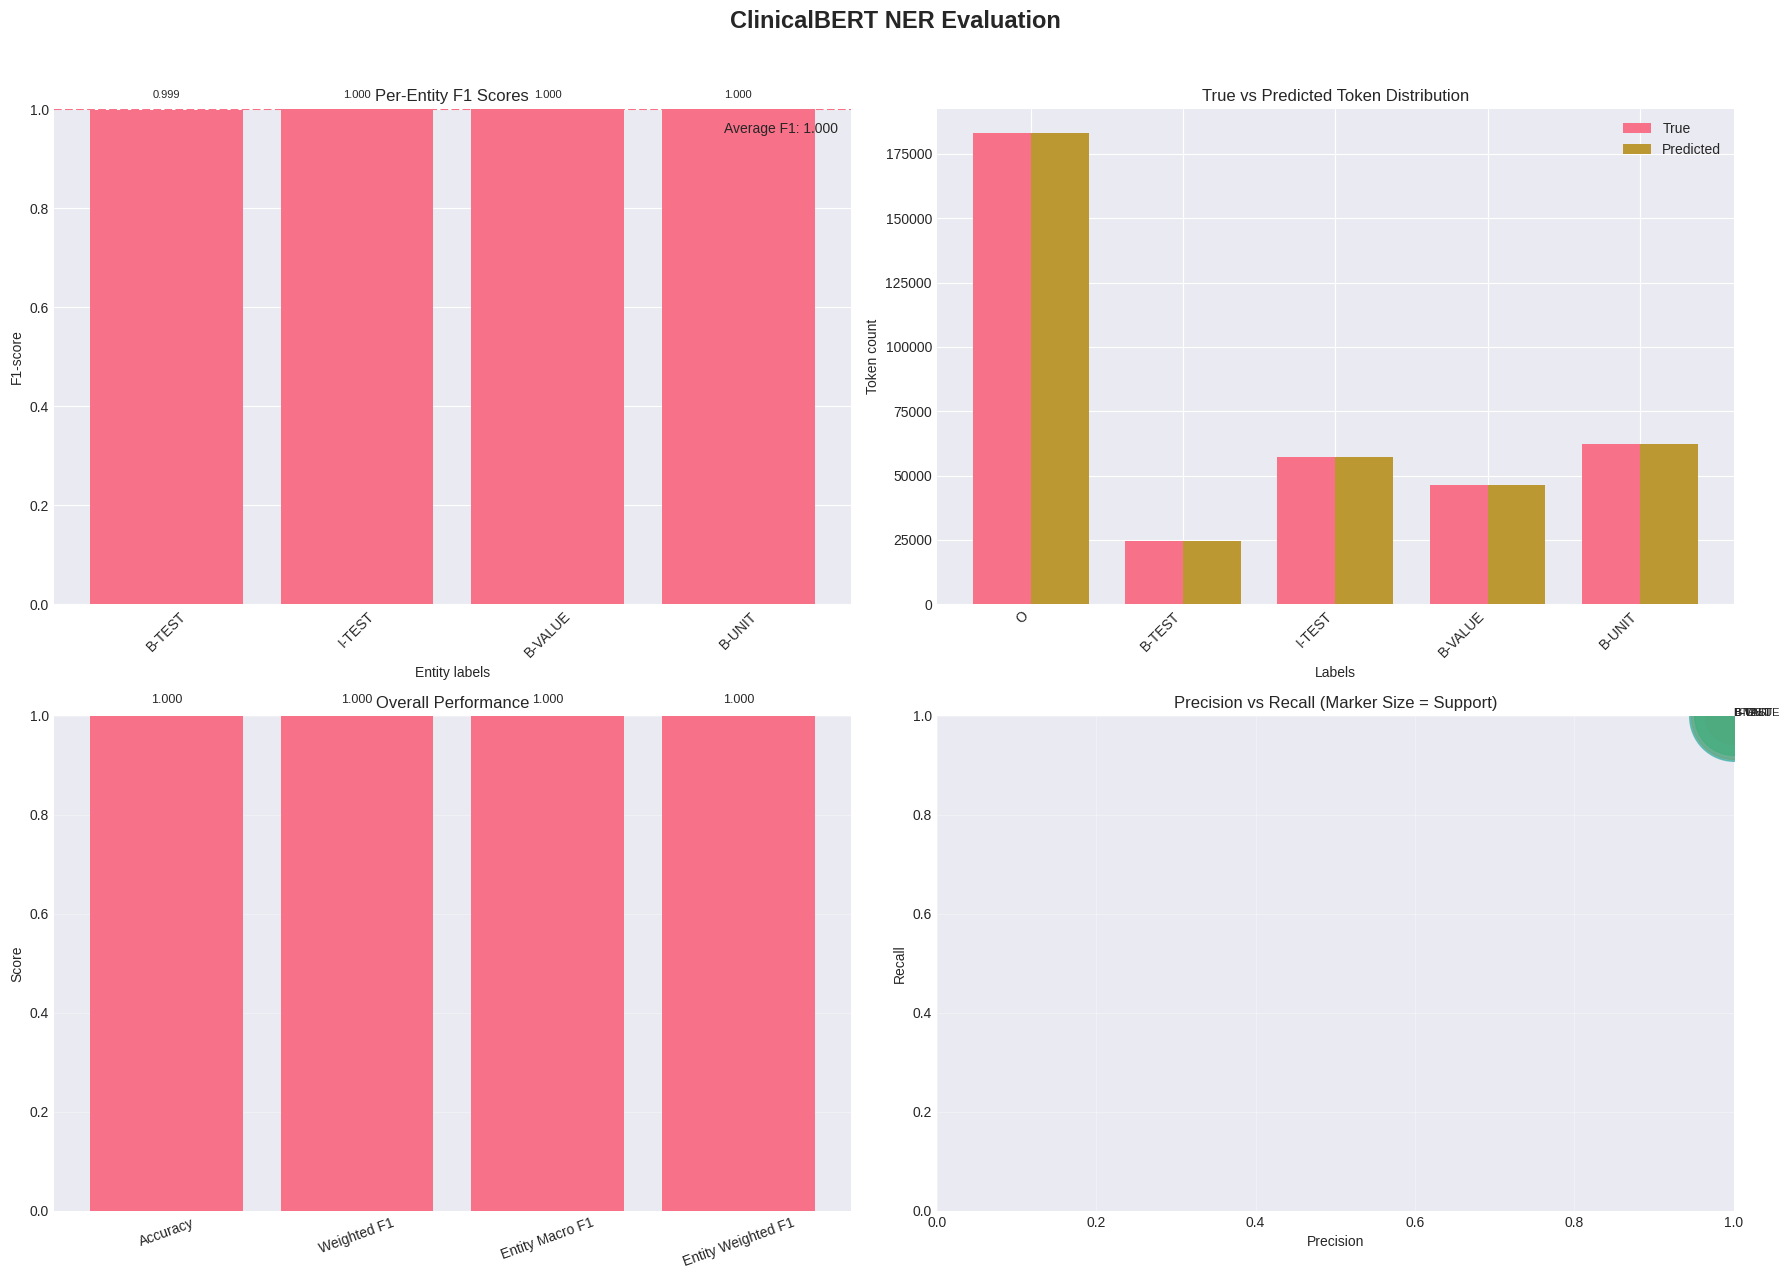

Performance plot saved to:
  /kaggle/working/clinicalbert_evaluation/per_label_performance_detailed.png

Evaluation metrics saved to:
  /kaggle/working/clinicalbert_evaluation/evaluation_metrics.json

Evaluation report saved to:
  /kaggle/working/clinicalbert_evaluation/per_label_evaluation_report.txt

EVALUATION COMPLETE

Test samples:                3,245
Evaluated tokens:            373,556
Accuracy:                    0.9997
Weighted F1:                 0.9997
Entity macro F1:             0.9997
Entity weighted F1:          0.9997

Output directory:
/kaggle/working/clinicalbert_evaluation

Generated files:
- /kaggle/working/clinicalbert_evaluation/per_label_performance_detailed.png
- /kaggle/working/clinicalbert_evaluation/per_label_evaluation_report.txt
- /kaggle/working/clinicalbert_evaluation/evaluation_metrics.json
- /kaggle/working/clinicalbert_evaluation/test_predictions.csv
- /kaggle/working/clinicalbert_evaluation/confusion_matrix.csv



In [13]:
# ============================================================
# COMPLETE CORRECTED CLINICALBERT NER EVALUATION CODE
# ============================================================

import os
import json
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification
)


print("=" * 80)
print("CLINICALBERT NER - COMPLETE EVALUATION")
print("=" * 80)


# ============================================================
# 1. FILE PATHS
# ============================================================

TRAIN_NER_PATH = "/kaggle/working/train_ner.jsonl"
VAL_NER_PATH = "/kaggle/working/val_ner.jsonl"
TEST_NER_PATH = "/kaggle/working/test_ner.jsonl"

MODEL_PATH = "/kaggle/working/clinicalbert_ner_enhanced_final"

EVALUATION_OUTPUT_DIR = "/kaggle/working/clinicalbert_evaluation"
TEMP_EVAL_DIR = "/kaggle/working/temp_eval"

PLOT_PATH = os.path.join(
    EVALUATION_OUTPUT_DIR,
    "per_label_performance_detailed.png"
)

REPORT_PATH = os.path.join(
    EVALUATION_OUTPUT_DIR,
    "per_label_evaluation_report.txt"
)

METRICS_PATH = os.path.join(
    EVALUATION_OUTPUT_DIR,
    "evaluation_metrics.json"
)

PREDICTIONS_PATH = os.path.join(
    EVALUATION_OUTPUT_DIR,
    "test_predictions.csv"
)

CONFUSION_MATRIX_PATH = os.path.join(
    EVALUATION_OUTPUT_DIR,
    "confusion_matrix.csv"
)

os.makedirs(EVALUATION_OUTPUT_DIR, exist_ok=True)
os.makedirs(TEMP_EVAL_DIR, exist_ok=True)


# ============================================================
# 2. CHECK REQUIRED FILES
# ============================================================

required_paths = [
    TRAIN_NER_PATH,
    VAL_NER_PATH,
    TEST_NER_PATH,
    MODEL_PATH
]

print("\nChecking required paths...")

for required_path in required_paths:

    if not os.path.exists(required_path):
        raise FileNotFoundError(
            f"Required path not found:\n{required_path}"
        )

    print(f"  Found: {required_path}")


# ============================================================
# 3. LOAD NER DATA
# ============================================================

def load_ner_data(jsonl_file):
    """
    Load token-level NER data from JSONL.

    Expected format:
    {
        "tokens": [...],
        "ner_tags": [...],
        "source": "..."
    }
    """

    tokens = []
    ner_tags = []
    sources = []

    with open(
        jsonl_file,
        "r",
        encoding="utf-8"
    ) as file:

        for line_number, line in enumerate(
            file,
            start=1
        ):
            line = line.strip()

            if not line:
                continue

            try:
                data = json.loads(line)

            except json.JSONDecodeError as error:
                raise ValueError(
                    f"Invalid JSON in {jsonl_file} "
                    f"at line {line_number}: {error}"
                )

            if "tokens" not in data:
                raise KeyError(
                    f"'tokens' missing in {jsonl_file} "
                    f"at line {line_number}"
                )

            if "ner_tags" not in data:
                raise KeyError(
                    f"'ner_tags' missing in {jsonl_file} "
                    f"at line {line_number}"
                )

            sample_tokens = data["tokens"]
            sample_tags = data["ner_tags"]

            if not isinstance(sample_tokens, list):
                raise TypeError(
                    f"'tokens' must be a list in "
                    f"{jsonl_file}, line {line_number}"
                )

            if not isinstance(sample_tags, list):
                raise TypeError(
                    f"'ner_tags' must be a list in "
                    f"{jsonl_file}, line {line_number}"
                )

            if len(sample_tokens) != len(sample_tags):
                raise ValueError(
                    f"Token/tag length mismatch in "
                    f"{jsonl_file}, line {line_number}: "
                    f"{len(sample_tokens)} tokens and "
                    f"{len(sample_tags)} tags"
                )

            if len(sample_tokens) == 0:
                continue

            tokens.append(
                [str(token) for token in sample_tokens]
            )

            ner_tags.append(
                [str(tag) for tag in sample_tags]
            )

            sources.append(
                str(data.get("source", "unknown"))
            )

    if len(tokens) == 0:
        raise ValueError(
            f"No valid samples found in {jsonl_file}"
        )

    return tokens, ner_tags, sources


print("\nLoading NER datasets...")

train_tokens, train_tags, train_sources = load_ner_data(
    TRAIN_NER_PATH
)

val_tokens, val_tags, val_sources = load_ner_data(
    VAL_NER_PATH
)

test_tokens, test_tags, test_sources = load_ner_data(
    TEST_NER_PATH
)

print(f"Training samples:   {len(train_tokens):,}")
print(f"Validation samples: {len(val_tokens):,}")
print(f"Test samples:       {len(test_tokens):,}")


# ============================================================
# 4. LOAD FINE-TUNED MODEL AND TOKENIZER
# ============================================================

print("\n" + "=" * 80)
print("LOADING FINE-TUNED MODEL")
print("=" * 80)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    use_fast=True
)

if not tokenizer.is_fast:
    raise ValueError(
        "A fast tokenizer is required for word alignment."
    )

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_PATH
)

print("Fine-tuned model loaded successfully.")


# ============================================================
# 5. USE SAVED MODEL LABEL MAPPING
# ============================================================

raw_id2label = model.config.id2label
raw_label2id = model.config.label2id

id2label = {
    int(label_id): label
    for label_id, label in raw_id2label.items()
}

label2id = {
    label: int(label_id)
    for label, label_id in raw_label2id.items()
}

label_list = [
    id2label[index]
    for index in range(len(id2label))
]

number_of_labels = len(label_list)

print(f"\nNumber of labels: {number_of_labels}")

print("\nSaved model label mapping:")

for label_id in range(number_of_labels):
    print(
        f"  {label_id}: "
        f"{id2label[label_id]}"
    )


# ============================================================
# 6. VALIDATE DATASET LABELS AGAINST MODEL
# ============================================================

dataset_labels = sorted({
    tag
    for dataset_tags in [
        train_tags,
        val_tags,
        test_tags
    ]
    for tag_sequence in dataset_tags
    for tag in tag_sequence
})

print("\nLabels found in NER datasets:")

for label in dataset_labels:
    print(f"  {label}")

missing_labels = [
    label
    for label in dataset_labels
    if label not in label2id
]

if missing_labels:
    raise ValueError(
        "The following dataset labels are not present "
        "in the trained model label mapping:\n"
        + "\n".join(
            f"  - {label}"
            for label in missing_labels
        )
    )

model_labels_missing_from_test = [
    label
    for label in label_list
    if label not in {
        tag
        for sequence in test_tags
        for tag in sequence
    }
]

if model_labels_missing_from_test:
    print(
        "\nWarning: The following model labels are not "
        "present in the test set:"
    )

    for label in model_labels_missing_from_test:
        print(f"  - {label}")


# ============================================================
# 7. SET MAXIMUM SEQUENCE LENGTH
# ============================================================

MAX_LENGTH = 128

print(
    f"\nMaximum evaluation sequence length: "
    f"{MAX_LENGTH}"
)


# ============================================================
# 8. TOKENIZE AND ALIGN BIO LABELS
# ============================================================

def tokenize_and_align(examples):
    """
    Tokenize pre-split words and align BIO labels with
    ClinicalBERT word pieces.

    Continuation word pieces convert B-X to I-X when
    the corresponding I-X label exists.
    """

    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        is_split_into_words=True
    )

    aligned_labels = []

    for batch_index, tag_sequence in enumerate(
        examples["ner_tags"]
    ):
        word_ids = tokenized_inputs.word_ids(
            batch_index=batch_index
        )

        label_ids = []
        previous_word_index = None

        for word_index in word_ids:

            if word_index is None:
                label_ids.append(-100)

            elif word_index != previous_word_index:
                original_tag = tag_sequence[word_index]

                if original_tag not in label2id:
                    raise ValueError(
                        f"Unknown dataset label: "
                        f"{original_tag}"
                    )

                label_ids.append(
                    label2id[original_tag]
                )

            else:
                original_tag = tag_sequence[word_index]

                if original_tag.startswith("B-"):
                    inside_tag = (
                        "I-" + original_tag[2:]
                    )

                    if inside_tag in label2id:
                        original_tag = inside_tag

                if original_tag not in label2id:
                    raise ValueError(
                        f"Unknown continuation label: "
                        f"{original_tag}"
                    )

                label_ids.append(
                    label2id[original_tag]
                )

            previous_word_index = word_index

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels

    return tokenized_inputs


# ============================================================
# 9. CREATE TEST DATASET
# ============================================================

print("\n" + "=" * 80)
print("PREPARING TEST DATASET")
print("=" * 80)

test_dataset = Dataset.from_dict(
    {
        "tokens": test_tokens,
        "ner_tags": test_tags,
        "source": test_sources
    }
)

test_dataset = test_dataset.map(
    tokenize_and_align,
    batched=True,
    desc="Tokenizing test data"
)

print(
    f"Tokenized test samples: "
    f"{len(test_dataset):,}"
)


# ============================================================
# 10. PREPARE DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model.to(device)
model.eval()

print(f"\nUsing device: {device}")

if torch.cuda.is_available():
    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )


# ============================================================
# 11. CREATE EVALUATION TRAINER
# ============================================================

evaluation_args = TrainingArguments(
    output_dir=TEMP_EVAL_DIR,
    per_device_eval_batch_size=8,
    report_to="none",
    remove_unused_columns=True,
    fp16=torch.cuda.is_available()
)

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)

trainer = Trainer(
    model=model,
    args=evaluation_args,
    data_collator=data_collator,
    processing_class=tokenizer
)


# ============================================================
# 12. GENERATE TEST PREDICTIONS
# ============================================================

print("\n" + "=" * 80)
print("GENERATING TEST PREDICTIONS")
print("=" * 80)

prediction_output = trainer.predict(
    test_dataset
)

logits = prediction_output.predictions
true_label_ids = prediction_output.label_ids

predicted_label_ids = np.argmax(
    logits,
    axis=2
)

print(
    f"Prediction array shape: "
    f"{predicted_label_ids.shape}"
)


# ============================================================
# 13. FLATTEN VALID TOKEN PREDICTIONS
# ============================================================

flat_predictions = []
flat_labels = []

for prediction_sequence, label_sequence in zip(
    predicted_label_ids,
    true_label_ids
):
    for predicted_id, label_id in zip(
        prediction_sequence,
        label_sequence
    ):
        if label_id != -100:
            flat_predictions.append(
                int(predicted_id)
            )

            flat_labels.append(
                int(label_id)
            )

if len(flat_labels) == 0:
    raise ValueError(
        "No valid labels were found after tokenization."
    )

print(
    f"Total evaluated tokens: "
    f"{len(flat_labels):,}"
)


# ============================================================
# 14. TRUE TOKEN DISTRIBUTION
# ============================================================

true_label_counter = Counter(
    id2label[label_id]
    for label_id in flat_labels
)

print("\n" + "=" * 80)
print("TRUE TOKEN DISTRIBUTION")
print("=" * 80)

for label_name, count in true_label_counter.most_common():
    percentage = (
        count / len(flat_labels) * 100
    )

    print(
        f"  {label_name}: "
        f"{count:,} "
        f"({percentage:.2f}%)"
    )


# ============================================================
# 15. PREDICTED TOKEN DISTRIBUTION
# ============================================================

predicted_label_counter = Counter(
    id2label[label_id]
    for label_id in flat_predictions
)

print("\n" + "=" * 80)
print("PREDICTED TOKEN DISTRIBUTION")
print("=" * 80)

for label_name, count in (
    predicted_label_counter.most_common()
):
    percentage = (
        count / len(flat_predictions) * 100
    )

    print(
        f"  {label_name}: "
        f"{count:,} "
        f"({percentage:.2f}%)"
    )


# ============================================================
# 16. CALCULATE PER-LABEL METRICS
# ============================================================

all_label_ids = list(
    range(number_of_labels)
)

precision, recall, f1_scores, support = (
    precision_recall_fscore_support(
        flat_labels,
        flat_predictions,
        labels=all_label_ids,
        average=None,
        zero_division=0
    )
)

per_label_results = []

for label_id in all_label_ids:

    label_name = id2label[label_id]

    per_label_results.append(
        {
            "Label_ID": label_id,
            "Label": label_name,
            "Precision": float(
                precision[label_id]
            ),
            "Recall": float(
                recall[label_id]
            ),
            "F1-Score": float(
                f1_scores[label_id]
            ),
            "Support": int(
                support[label_id]
            ),
            "Predicted_Count": int(
                predicted_label_counter.get(
                    label_name,
                    0
                )
            ),
            "Is_Entity": label_name != "O"
        }
    )

per_label_df = pd.DataFrame(
    per_label_results
)

entity_df = per_label_df[
    per_label_df["Is_Entity"]
].copy()


# ============================================================
# 17. CALCULATE OVERALL METRICS
# ============================================================

overall_accuracy = accuracy_score(
    flat_labels,
    flat_predictions
)

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        flat_labels,
        flat_predictions,
        average="weighted",
        zero_division=0
    )
)

macro_precision, macro_recall, macro_f1_all, _ = (
    precision_recall_fscore_support(
        flat_labels,
        flat_predictions,
        average="macro",
        zero_division=0
    )
)

entity_label_ids = [
    label_id
    for label_id, label_name in id2label.items()
    if label_name != "O"
]

if entity_label_ids:

    (
        entity_macro_precision,
        entity_macro_recall,
        entity_macro_f1,
        _
    ) = precision_recall_fscore_support(
        flat_labels,
        flat_predictions,
        labels=entity_label_ids,
        average="macro",
        zero_division=0
    )

    (
        entity_weighted_precision,
        entity_weighted_recall,
        entity_weighted_f1,
        _
    ) = precision_recall_fscore_support(
        flat_labels,
        flat_predictions,
        labels=entity_label_ids,
        average="weighted",
        zero_division=0
    )

else:
    entity_macro_precision = 0.0
    entity_macro_recall = 0.0
    entity_macro_f1 = 0.0

    entity_weighted_precision = 0.0
    entity_weighted_recall = 0.0
    entity_weighted_f1 = 0.0


# ============================================================
# 18. DISPLAY PER-LABEL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("PER-LABEL PERFORMANCE")
print("=" * 80)

print(
    per_label_df[
        [
            "Label",
            "Precision",
            "Recall",
            "F1-Score",
            "Support",
            "Predicted_Count"
        ]
    ].to_string(
        index=False,
        float_format=lambda value: f"{value:.4f}"
    )
)


print("\n" + "=" * 80)
print("ENTITY-ONLY PERFORMANCE")
print("=" * 80)

if len(entity_df) > 0:

    print(
        entity_df[
            [
                "Label",
                "Precision",
                "Recall",
                "F1-Score",
                "Support",
                "Predicted_Count"
            ]
        ].to_string(
            index=False,
            float_format=lambda value: f"{value:.4f}"
        )
    )

else:
    print("No entity labels were found.")


# ============================================================
# 19. DISPLAY OVERALL METRICS
# ============================================================

print("\n" + "=" * 80)
print("OVERALL METRICS")
print("=" * 80)

print(
    f"Accuracy:                  "
    f"{overall_accuracy:.4f}"
)

print(
    f"Weighted precision:        "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted recall:           "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1:               "
    f"{weighted_f1:.4f}"
)

print(
    f"Macro F1 including O:      "
    f"{macro_f1_all:.4f}"
)

print(
    f"Entity macro precision:    "
    f"{entity_macro_precision:.4f}"
)

print(
    f"Entity macro recall:       "
    f"{entity_macro_recall:.4f}"
)

print(
    f"Entity macro F1:           "
    f"{entity_macro_f1:.4f}"
)

print(
    f"Entity weighted F1:        "
    f"{entity_weighted_f1:.4f}"
)


# ============================================================
# 20. COMPLETE CONFUSION MATRIX
# ============================================================

confusion_matrix_values = confusion_matrix(
    flat_labels,
    flat_predictions,
    labels=all_label_ids
)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix_values,
    index=[
        f"True_{label}"
        for label in label_list
    ],
    columns=[
        f"Pred_{label}"
        for label in label_list
    ]
)

confusion_matrix_df.to_csv(
    CONFUSION_MATRIX_PATH
)

print("\n" + "=" * 80)
print("CORRECT PREDICTIONS PER ENTITY")
print("=" * 80)

for label_id in entity_label_ids:

    label_name = id2label[label_id]

    correct = int(
        confusion_matrix_values[
            label_id,
            label_id
        ]
    )

    total = int(
        confusion_matrix_values[
            label_id,
            :
        ].sum()
    )

    percentage = (
        correct / total * 100
        if total > 0
        else 0
    )

    print(
        f"  {label_name}: "
        f"{correct:,}/{total:,} "
        f"({percentage:.2f}%)"
    )

print(
    f"\nConfusion matrix saved to:\n"
    f"  {CONFUSION_MATRIX_PATH}"
)


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

classification_report_text = classification_report(
    flat_labels,
    flat_predictions,
    labels=all_label_ids,
    target_names=label_list,
    zero_division=0,
    digits=4
)

print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 80)

print(classification_report_text)


# ============================================================
# 22. SAVE TOKEN-LEVEL PREDICTIONS
# ============================================================

prediction_records = []

for true_id, predicted_id in zip(
    flat_labels,
    flat_predictions
):
    prediction_records.append(
        {
            "True_Label_ID": true_id,
            "True_Label": id2label[true_id],
            "Predicted_Label_ID": predicted_id,
            "Predicted_Label": id2label[
                predicted_id
            ],
            "Correct": true_id == predicted_id
        }
    )

predictions_df = pd.DataFrame(
    prediction_records
)

predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print(
    f"\nToken-level predictions saved to:\n"
    f"  {PREDICTIONS_PATH}"
)


# ============================================================
# 23. VISUALIZATIONS
# ============================================================

print("\nCreating performance visualizations...")

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 13)
)

fig.suptitle(
    "ClinicalBERT NER Evaluation",
    fontsize=17,
    fontweight="bold"
)


# ------------------------------------------------------------
# Plot 1: Per-entity F1 scores
# ------------------------------------------------------------

ax1 = axes[0, 0]

if len(entity_df) > 0:

    bars1 = ax1.bar(
        entity_df["Label"],
        entity_df["F1-Score"]
    )

    ax1.set_xlabel("Entity labels")
    ax1.set_ylabel("F1-score")
    ax1.set_title("Per-Entity F1 Scores")
    ax1.set_ylim(0, 1)
    ax1.tick_params(
        axis="x",
        rotation=45
    )

    average_entity_f1 = (
        entity_df["F1-Score"].mean()
    )

    ax1.axhline(
        y=average_entity_f1,
        linestyle="--",
        label=(
            f"Average F1: "
            f"{average_entity_f1:.3f}"
        )
    )

    ax1.legend()

    for bar in bars1:
        height = bar.get_height()

        ax1.text(
            bar.get_x()
            + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

else:
    ax1.text(
        0.5,
        0.5,
        "No entity labels",
        ha="center",
        va="center"
    )


# ------------------------------------------------------------
# Plot 2: True and predicted token distribution
# ------------------------------------------------------------

ax2 = axes[0, 1]

x_positions = np.arange(
    len(label_list)
)

bar_width = 0.38

true_counts_plot = [
    true_label_counter.get(
        label,
        0
    )
    for label in label_list
]

predicted_counts_plot = [
    predicted_label_counter.get(
        label,
        0
    )
    for label in label_list
]

ax2.bar(
    x_positions - bar_width / 2,
    true_counts_plot,
    width=bar_width,
    label="True"
)

ax2.bar(
    x_positions + bar_width / 2,
    predicted_counts_plot,
    width=bar_width,
    label="Predicted"
)

ax2.set_xlabel("Labels")
ax2.set_ylabel("Token count")
ax2.set_title(
    "True vs Predicted Token Distribution"
)

ax2.set_xticks(x_positions)
ax2.set_xticklabels(
    label_list,
    rotation=45,
    ha="right"
)

ax2.legend()


# ------------------------------------------------------------
# Plot 3: Overall metric summary
# ------------------------------------------------------------

ax3 = axes[1, 0]

metric_names = [
    "Accuracy",
    "Weighted F1",
    "Entity Macro F1",
    "Entity Weighted F1"
]

metric_values = [
    overall_accuracy,
    weighted_f1,
    entity_macro_f1,
    entity_weighted_f1
]

bars3 = ax3.bar(
    metric_names,
    metric_values
)

ax3.set_ylabel("Score")
ax3.set_title("Overall Performance")
ax3.set_ylim(0, 1)
ax3.tick_params(
    axis="x",
    rotation=20
)

ax3.grid(
    True,
    alpha=0.3,
    axis="y"
)

for bar in bars3:
    height = bar.get_height()

    ax3.text(
        bar.get_x()
        + bar.get_width() / 2,
        height + 0.02,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )


# ------------------------------------------------------------
# Plot 4: Precision versus recall
# ------------------------------------------------------------

ax4 = axes[1, 1]

if len(entity_df) > 0:

    for _, row in entity_df.iterrows():

        marker_size = (
            row["Support"] / 15 + 30
        )

        ax4.scatter(
            row["Precision"],
            row["Recall"],
            s=marker_size,
            alpha=0.65
        )

        ax4.annotate(
            row["Label"],
            (
                row["Precision"],
                row["Recall"]
            ),
            fontsize=8
        )

    ax4.set_xlabel("Precision")
    ax4.set_ylabel("Recall")
    ax4.set_title(
        "Precision vs Recall "
        "(Marker Size = Support)"
    )

    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)

    ax4.grid(
        True,
        alpha=0.3
    )

else:
    ax4.text(
        0.5,
        0.5,
        "No entity labels",
        ha="center",
        va="center"
    )


plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Performance plot saved to:\n"
    f"  {PLOT_PATH}"
)


# ============================================================
# 24. SAVE METRICS AS JSON
# ============================================================

evaluation_metrics = {
    "model_path": MODEL_PATH,
    "test_file": TEST_NER_PATH,
    "test_samples": len(test_tokens),
    "evaluated_tokens": len(flat_labels),
    "max_length": MAX_LENGTH,
    "number_of_labels": number_of_labels,
    "label_mapping": {
        str(label_id): label_name
        for label_id, label_name in id2label.items()
    },
    "overall_metrics": {
        "accuracy": float(
            overall_accuracy
        ),
        "weighted_precision": float(
            weighted_precision
        ),
        "weighted_recall": float(
            weighted_recall
        ),
        "weighted_f1": float(
            weighted_f1
        ),
        "macro_precision_all_labels": float(
            macro_precision
        ),
        "macro_recall_all_labels": float(
            macro_recall
        ),
        "macro_f1_all_labels": float(
            macro_f1_all
        ),
        "entity_macro_precision": float(
            entity_macro_precision
        ),
        "entity_macro_recall": float(
            entity_macro_recall
        ),
        "entity_macro_f1": float(
            entity_macro_f1
        ),
        "entity_weighted_precision": float(
            entity_weighted_precision
        ),
        "entity_weighted_recall": float(
            entity_weighted_recall
        ),
        "entity_weighted_f1": float(
            entity_weighted_f1
        )
    },
    "per_label_metrics": per_label_results,
    "true_token_distribution": dict(
        true_label_counter
    ),
    "predicted_token_distribution": dict(
        predicted_label_counter
    )
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        evaluation_metrics,
        file,
        indent=2
    )

print(
    f"\nEvaluation metrics saved to:\n"
    f"  {METRICS_PATH}"
)


# ============================================================
# 25. GENERATE TEXT REPORT
# ============================================================

report_text = f"""
CLINICALBERT NER EVALUATION REPORT
==================================

MODEL
-----
Model path: {MODEL_PATH}

DATASET
-------
Test file: {TEST_NER_PATH}
Test samples: {len(test_tokens):,}
Evaluated tokens: {len(flat_labels):,}
Maximum sequence length: {MAX_LENGTH}
Number of labels: {number_of_labels}

LABEL MAPPING
-------------
{chr(10).join(
    f"{label_id}: {label_name}"
    for label_id, label_name in id2label.items()
)}

OVERALL PERFORMANCE
-------------------
Accuracy: {overall_accuracy:.6f}
Weighted precision: {weighted_precision:.6f}
Weighted recall: {weighted_recall:.6f}
Weighted F1: {weighted_f1:.6f}
Macro F1 including O: {macro_f1_all:.6f}

ENTITY-ONLY PERFORMANCE
-----------------------
Entity macro precision: {entity_macro_precision:.6f}
Entity macro recall: {entity_macro_recall:.6f}
Entity macro F1: {entity_macro_f1:.6f}
Entity weighted F1: {entity_weighted_f1:.6f}

TRUE TOKEN DISTRIBUTION
-----------------------
{chr(10).join(
    f"{label}: {count:,} "
    f"({count / len(flat_labels) * 100:.2f}%)"
    for label, count
    in true_label_counter.most_common()
)}

PREDICTED TOKEN DISTRIBUTION
----------------------------
{chr(10).join(
    f"{label}: {count:,} "
    f"({count / len(flat_predictions) * 100:.2f}%)"
    for label, count
    in predicted_label_counter.most_common()
)}

PER-LABEL METRICS
-----------------
{per_label_df[
    [
        "Label",
        "Precision",
        "Recall",
        "F1-Score",
        "Support",
        "Predicted_Count"
    ]
].to_string(index=False)}

CLASSIFICATION REPORT
---------------------
{classification_report_text}

Generated: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)

print(
    f"\nEvaluation report saved to:\n"
    f"  {REPORT_PATH}"
)


# ============================================================
# 26. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("EVALUATION COMPLETE")
print("=" * 80)

print(f"""
Test samples:                {len(test_tokens):,}
Evaluated tokens:            {len(flat_labels):,}
Accuracy:                    {overall_accuracy:.4f}
Weighted F1:                 {weighted_f1:.4f}
Entity macro F1:             {entity_macro_f1:.4f}
Entity weighted F1:          {entity_weighted_f1:.4f}

Output directory:
{EVALUATION_OUTPUT_DIR}

Generated files:
- {PLOT_PATH}
- {REPORT_PATH}
- {METRICS_PATH}
- {PREDICTIONS_PATH}
- {CONFUSION_MATRIX_PATH}
""")

# **Inference on Medical Reports Image using PaddleOCR with Finetuned Model.**

# **New Approach**

try1

In [14]:
"""
Medical Report Analysis Pipeline - CLEAN CONVERTER OUTPUT
"""

try:
    from paddleocr import PaddleOCR
    PADDLE_AVAILABLE = True
except ImportError:
    PADDLE_AVAILABLE = False
    print("PaddleOCR not installed.")

try:
    from pdf2image import convert_from_path
    PDF_AVAILABLE = True
except ImportError:
    PDF_AVAILABLE = False
    print("pdf2image not installed.")

import tempfile
import re
import json
import pandas as pd
from collections import defaultdict

print("="*80)
print("MEDICAL REPORT ANALYSIS - CLEAN CONVERTER OUTPUT")
print("="*80)

# ============================================
# PART 1: LOAD MIMIC LABELS
# ============================================

print("\n📂 Loading MIMIC labels...")

mimic3_labels = []
try:
    d_labitems_iii = pd.read_csv('/kaggle/input/datasets/samtajainj/d-labitems2/D_LABITEMS.csv')
    mimic3_labels = d_labitems_iii['label'].dropna().unique().tolist()
    print(f"  MIMIC-III: {len(mimic3_labels):,} lab tests")
except:
    print(f"  MIMIC-III not found")

mimic4_labels = []
try:
    d_labitems_iv = pd.read_csv('/kaggle/input/datasets/montassarba/mimic-iv-clinical-database-demo-2-2/mimic-iv-clinical-database-demo-2.2/hosp/d_labitems.csv')
    mimic4_labels = d_labitems_iv['label'].dropna().unique().tolist()
    print(f"  MIMIC-IV: {len(mimic4_labels):,} lab tests")
except:
    print(f"  MIMIC-IV not found")

custom_labels = []
try:
    with open('/kaggle/input/datasets/samtajainj/kept-lab-labels2/kept_lab_labels.txt', 'r') as f:
        custom_labels = [line.strip() for line in f.readlines() if line.strip()]
    print(f"  Custom labels: {len(custom_labels):,} tests")
except:
    print(f"  Custom labels not found")

all_labels = list(set(mimic3_labels + mimic4_labels + custom_labels))
print(f"\n  Total unique labels: {len(all_labels):,}")

# ============================================
# PART 2: OCR Extraction (EXACT WORKING CODE)
# ============================================

class MedicalReportOCR:
    """Extract text from medical report images and PDFs"""
    
    def __init__(self):
        self.ocr = None
        if PADDLE_AVAILABLE:
            try:
                self.ocr = PaddleOCR(lang='en', use_angle_cls=False)
                print("PaddleOCR initialized")
            except Exception as e:
                print(f"PaddleOCR initialization failed: {e}")
                self.ocr = None
        else:
            print("PaddleOCR not available")
    
    def extract_text_from_image(self, image_path):
        if self.ocr is None:
            print("OCR not available.")
            return ""
        
        try:
            result = self.ocr.predict(image_path)
            if result and isinstance(result, list) and len(result) > 0:
                if isinstance(result[0], dict) and 'rec_texts' in result[0]:
                    texts = result[0]['rec_texts']
                elif isinstance(result[0], list):
                    texts = [item[1][0] for item in result[0]] if result[0] else []
                else:
                    texts = []
                
                full_text = '\n'.join(texts)
                full_text = re.sub(r'\n{3,}', '\n\n', full_text)
                return full_text.strip()
            else:
                print("No text detected in image")
                return ""
        except Exception as e:
            print(f"Error extracting text from image: {e}")
            return self._fallback_ocr(image_path)
    
    def _fallback_ocr(self, image_path):
        try:
            import pytesseract
            from PIL import Image
            img = Image.open(image_path)
            text = pytesseract.image_to_string(img)
            return text.strip()
        except:
            print("Fallback OCR failed")
            return ""
    
    def extract_text_from_pdf(self, pdf_path):
        if not PDF_AVAILABLE:
            print("pdf2image not available")
            return ""
        
        try:
            pages = convert_from_path(pdf_path)
            texts = []
            for i, page in enumerate(pages):
                with tempfile.NamedTemporaryFile(suffix='.jpg') as f:
                    page.save(f.name)
                    text = self.extract_text_from_image(f.name)
                    if text:
                        texts.append(text)
                        print(f"  Processed page {i+1}/{len(pages)}")
            return '\n'.join(texts)
        except Exception as e:
            print(f"Error extracting text from PDF: {e}")
            return ""
    
    def extract(self, file_path):
        if file_path.lower().endswith('.pdf'):
            return self.extract_text_from_pdf(file_path)
        else:
            return self.extract_text_from_image(file_path)

# ============================================
# PART 3: Converter - CLEAN OUTPUT
# ============================================

class TableToNarrativeConverter:
    def __init__(self):
        # PRIMARY: Working patterns (these match OCR output perfectly)
        self.primary_patterns = {
            'WBC': r'(WBC|White Blood Cell|Leukocyte)\s*Count',
            'HEMOGLOBIN': r'(Hemoglobin|HGB|HB)',
            'HCT': r'(Hematocrit|HCT)',
            'PLATELETS': r'(Platelet|PLT)\s*Count',
            'MCV': r'\bMCV\b',
            'MCH': r'\bMCH\b',
            'MCHC': r'\bMCHC\b',
            'RDW': r'\bRDW\b',
            'NEUTROPHILS': r'(Neutrophils|NEUT)',
            'LYMPHOCYTES': r'(Lymphocytes|LYMPH)',
            'EOSINOPHILS': r'(Eosinophils|EOS)',
            'BASOPHILS': r'(Basophils|BASO)',
            'MONOCYTES': r'(Monocytes|MONO)',
            'GLUCOSE': r'\bGlucose\b',
            'SODIUM': r'(Sodium|Na)',
            'POTASSIUM': r'(Potassium|K)',
            'CHLORIDE': r'(Chloride|Cl)',
            'BICARBONATE': r'(Bicarbonate|CO2|HCO3)',
            'BUN': r'(BUN|Blood Urea Nitrogen)',
            'CREATININE': r'(Creatinine|Cr)',
            'CALCIUM': r'(Calcium|Ca)',
            'CHOLESTEROL': r'Total\s*Cholesterol',
            'HDL': r'HDL\s*Cholesterol',
            'LDL': r'LDL\s*Cholesterol',
            'TRIGLYCERIDES': r'(Triglycerides|TRIG)',
            'PT': r'\bPT\b',
            'PTT': r'\bPTT\b',
            'INR': r'\bINR\b',
            'CRP': r'(C-Reactive Protein|CRP)',
            'RBC': r'(RBC|Red Blood Cell|Erythrocyte)'
        }
        
        # SECONDARY: MIMIC patterns
        self.mimic_patterns = {}
        for label in all_labels:
            if len(label) > 2 and label not in self.primary_patterns:
                clean_label = re.sub(r'[^a-zA-Z0-9\s]', ' ', label)
                clean_label = ' '.join(clean_label.split())
                if len(clean_label) > 2:
                    self.mimic_patterns[label.upper()] = r'\b' + re.escape(clean_label) + r'\b'
        
        self.test_patterns = {**self.primary_patterns, **self.mimic_patterns}
        
        # Units
        self.units = {
            'WBC': '10^9/L', 'HEMOGLOBIN': 'g/dL', 'HCT': '%',
            'PLATELETS': '10^9/L', 'MCV': 'fL', 'NEUTROPHILS': '%',
            'LYMPHOCYTES': '%', 'EOSINOPHILS': '%', 'BASOPHILS': '%',
            'MONOCYTES': '%', 'GLUCOSE': 'mg/dL', 'SODIUM': 'mmol/L',
            'POTASSIUM': 'mmol/L', 'CHLORIDE': 'mmol/L',
            'BICARBONATE': 'mmol/L', 'BUN': 'mg/dL',
            'CREATININE': 'mg/dL', 'CALCIUM': 'mg/dL',
            'CHOLESTEROL': 'mg/dL', 'HDL': 'mg/dL', 'LDL': 'mg/dL',
            'TRIGLYCERIDES': 'mg/dL', 'PT': 'sec', 'PTT': 'sec',
            'INR': '', 'CRP': 'mg/L', 'RBC': '10^6/L'
        }
        
        self.number_pattern = r'\b(\d+\.?\d*)\b'
        self.skip_patterns = ['PATIENT', 'DATE', 'BIRTH', 'ID', 'PHYSICIAN', 'REPORT', 'PAGE', 'COMMENTS']
        
        # Track extracted data
        self.extracted_data = {}
        
        print(f"  Primary patterns: {len(self.primary_patterns)}")
        print(f"  MIMIC patterns: {len(self.mimic_patterns)}")
        print(f"  Total patterns: {len(self.test_patterns)}")
    
    def _fix_ocr_value(self, test_key, value_str):
        try:
            value = float(value_str)
            if test_key == 'HEMOGLOBIN' and 100 <= value <= 200:
                return str(value / 10)
            if test_key == 'POTASSIUM' and 20 <= value <= 99:
                return str(value / 10)
            if test_key == 'CALCIUM' and 80 <= value <= 99:
                return str(value / 10)
            if test_key == 'SODIUM' and 10 <= value <= 20:
                return str(value * 10)
            return value_str
        except:
            return value_str
    
    def convert(self, text):
        lines = text.split('\n')
        narrative_parts = []
        processed_tests = set()
        self.extracted_data = {}
        
        # Priority order for tests (to avoid duplicates)
        test_priority = {
            'WBC': 1, 'HEMOGLOBIN': 1, 'HCT': 1, 'PLATELETS': 1, 'MCV': 1,
            'NEUTROPHILS': 1, 'LYMPHOCYTES': 1, 'MONOCYTES': 1, 'EOSINOPHILS': 1, 'BASOPHILS': 1,
            'GLUCOSE': 1, 'SODIUM': 1, 'POTASSIUM': 1, 'CHLORIDE': 1, 'BICARBONATE': 1,
            'BUN': 1, 'CREATININE': 1, 'CALCIUM': 1,
            'CHOLESTEROL': 1, 'HDL': 1, 'LDL': 1, 'TRIGLYCERIDES': 1,
            'PT': 1, 'PTT': 1, 'INR': 1, 'CRP': 1, 'RBC': 1
        }
        
        for line in lines:
            line = line.strip()
            if not line or len(line) < 3:
                continue
            
            if any(p in line for p in self.skip_patterns):
                continue
            
            line = re.sub(r'[^\w\s\.\-,\'\/\(\)\%\^]', ' ', line)
            line = re.sub(r'\s+', ' ', line).strip()
            
            # Check for each test
            for test_key, pattern in self.test_patterns.items():
                if test_key in processed_tests:
                    continue
                    
                if re.search(pattern, line, re.IGNORECASE):
                    numbers = re.findall(self.number_pattern, line)
                    
                    if numbers:
                        value = numbers[0]
                        fixed_value = self._fix_ocr_value(test_key, value)
                        unit = self.units.get(test_key, '')
                        
                        # Store extracted data (only if not already stored)
                        if test_key not in self.extracted_data:
                            self.extracted_data[test_key] = {
                                'test': test_key,
                                'value': fixed_value,
                                'unit': unit
                            }
                            
                            # Add to narrative (ONCE per test)
                            unit_text = f" {unit}" if unit else ""
                            narrative_parts.append(f"{test_key.lower()} {fixed_value}{unit_text}")
                            processed_tests.add(test_key)
                            break
        
        if narrative_parts:
            return "LABORATORY RESULTS\n" + "-"*40 + "\n" + "\n".join(narrative_parts)
        
        return text
    
    def get_extracted_data(self):
        return self.extracted_data

# ============================================
# PART 4: ClinicalBERT NER
# ============================================

class ClinicalBERTNER:
    def __init__(self, model_path="/kaggle/working/clinicalbert_ner_enhanced_final"):
        print(f"\nLoading ClinicalBERT model...")
        from transformers import AutoTokenizer, AutoModelForTokenClassification
        import torch
        
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForTokenClassification.from_pretrained(
            model_path, ignore_mismatched_sizes=True
        )
        self.model.eval()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.id2label = self.model.config.id2label
        print(f"Model loaded on {self.device}")
        print(f"   Labels: {list(self.id2label.values())}")
    
    def predict(self, text):
        import torch
        
        if not text or len(text.strip()) < 5:
            return [], []
        
        tokens = text.split()
        if len(tokens) > 1000:
            tokens = tokens[:1000]
            print(f"Truncated to first 1000 tokens")
        
        encoding = self.tokenizer(
            tokens,
            truncation=True,
            padding='max_length',
            max_length=256,  # Increased from 128
            is_split_into_words=True,
            return_tensors='pt'
        )
        
        word_ids = encoding.word_ids(batch_index=0)
        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)
        
        with torch.no_grad():
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=2)
        
        pred_tags = []
        prev_word_idx = None
        
        for i, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx != prev_word_idx:
                if word_idx < len(tokens):
                    pred_tags.append(self.id2label[predictions[0][i].item()])
                    prev_word_idx = word_idx
        
        while len(pred_tags) < len(tokens):
            pred_tags.append('O')
        while len(pred_tags) > len(tokens):
            pred_tags.pop()
        
        return tokens, pred_tags

# ============================================
# PART 5: NER Processor (IMPROVED)
# ============================================

class NERProcessor:
    def __init__(self):
        self.reference_ranges = {
            'WBC': {'unit': '10^9/L', 'normal': (4.0, 11.0), 'name': 'WBC'},
            'HEMOGLOBIN': {'unit': 'g/dL', 'normal': (13.0, 17.0), 'name': 'Hemoglobin'},
            'HCT': {'unit': '%', 'normal': (40.0, 50.0), 'name': 'Hematocrit'},
            'PLATELETS': {'unit': '10^9/L', 'normal': (150, 450), 'name': 'Platelets'},
            'MCV': {'unit': 'fL', 'normal': (83.0, 101.0), 'name': 'MCV'},
            'MCH': {'unit': 'pg', 'normal': (27.0, 32.0), 'name': 'MCH'},
            'MCHC': {'unit': 'g/dL', 'normal': (31.5, 34.5), 'name': 'MCHC'},
            'RDW': {'unit': '%', 'normal': (11.5, 14.5), 'name': 'RDW'},
            'NEUTROPHILS': {'unit': '%', 'normal': (40.0, 80.0), 'name': 'Neutrophils'},
            'LYMPHOCYTES': {'unit': '%', 'normal': (20.0, 40.0), 'name': 'Lymphocytes'},
            'EOSINOPHILS': {'unit': '%', 'normal': (1.0, 6.0), 'name': 'Eosinophils'},
            'BASOPHILS': {'unit': '%', 'normal': (0.0, 2.0), 'name': 'Basophils'},
            'MONOCYTES': {'unit': '%', 'normal': (2.0, 10.0), 'name': 'Monocytes'},
            'GLUCOSE': {'unit': 'mg/dL', 'normal': (70.0, 100.0), 'name': 'Glucose'},
            'SODIUM': {'unit': 'mmol/L', 'normal': (135.0, 145.0), 'name': 'Sodium'},
            'POTASSIUM': {'unit': 'mmol/L', 'normal': (3.5, 5.1), 'name': 'Potassium'},
            'CHLORIDE': {'unit': 'mmol/L', 'normal': (98.0, 107.0), 'name': 'Chloride'},
            'BICARBONATE': {'unit': 'mmol/L', 'normal': (22.0, 29.0), 'name': 'Bicarbonate'},
            'BUN': {'unit': 'mg/dL', 'normal': (7.0, 20.0), 'name': 'BUN'},
            'CREATININE': {'unit': 'mg/dL', 'normal': (0.70, 1.30), 'name': 'Creatinine'},
            'CALCIUM': {'unit': 'mg/dL', 'normal': (8.5, 10.5), 'name': 'Calcium'},
            'CHOLESTEROL': {'unit': 'mg/dL', 'normal': (0, 200), 'name': 'Total Cholesterol'},
            'HDL': {'unit': 'mg/dL', 'normal': (40, 60), 'name': 'HDL Cholesterol'},
            'LDL': {'unit': 'mg/dL', 'normal': (0, 130), 'name': 'LDL Cholesterol'},
            'TRIGLYCERIDES': {'unit': 'mg/dL', 'normal': (0, 150), 'name': 'Triglycerides'},
            'CRP': {'unit': 'mg/L', 'normal': (0, 5.0), 'name': 'C-Reactive Protein'},
            'RBC': {'unit': '10^6/L', 'normal': (4.5, 5.5), 'name': 'RBC'}
        }
    
    def process(self, tokens, ner_tags):
        if not tokens or not ner_tags:
            return {'lab_results': []}
        
        entities = []
        i = 0
        while i < len(tokens):
            if ner_tags[i].startswith('B-'):
                entity_type = ner_tags[i][2:]
                entity_tokens = [tokens[i]]
                j = i + 1
                while j < len(tokens) and ner_tags[j].startswith('I-'):
                    entity_tokens.append(tokens[j])
                    j += 1
                entities.append({
                    'type': entity_type,
                    'text': ' '.join(entity_tokens),
                    'start': i,
                    'end': j
                })
                i = j
            else:
                i += 1
        
        lab_results = []
        i = 0
        while i < len(entities):
            if entities[i]['type'] == 'TEST':
                lab = {'test': entities[i]['text']}
                i += 1
                
                # Look for VALUE and UNIT after this TEST
                while i < len(entities):
                    curr = entities[i]
                    if curr['type'] == 'TEST':
                        break
                    if curr['type'] == 'VALUE' and 'value' not in lab:
                        lab['value'] = curr['text']
                        i += 1
                    elif curr['type'] == 'UNIT' and 'unit' not in lab:
                        lab['unit'] = curr['text']
                        i += 1
                    else:
                        i += 1
                
                if 'value' in lab:
                    lab_results.append(lab)
            else:
                i += 1
        
        # Clean up results and add status
        cleaned_results = []
        seen_tests = set()
        
        for lab in lab_results:
            test = lab.get('test', '').upper()
            
            # Skip duplicates
            if test in seen_tests:
                continue
            seen_tests.add(test)
            
            # Try to match with reference ranges
            for key, ref in self.reference_ranges.items():
                if key in test or test in key:
                    if 'unit' not in lab or not lab['unit']:
                        lab['unit'] = ref['unit']
                    lab['test_name'] = ref['name']
                    
                    if 'value' in lab:
                        try:
                            val = float(lab['value'].replace(',', ''))
                            low, high = ref['normal']
                            if val < low:
                                lab['status'] = 'LOW'
                            elif val > high:
                                lab['status'] = 'HIGH'
                            else:
                                lab['status'] = 'NORMAL'
                        except:
                            lab['status'] = 'UNKNOWN'
                    break
            
            cleaned_results.append(lab)
        
        return {'lab_results': cleaned_results}

# ============================================
# PART 6: Complete Pipeline
# ============================================

class MedicalReportPipeline:
    def __init__(self, model_path="./clinicalbert_ner_enhanced_final"):
        self.ocr = MedicalReportOCR()
        self.converter = TableToNarrativeConverter()
        self.ner = ClinicalBERTNER(model_path)
        self.processor = NERProcessor()
    
    def process_file(self, file_path):
        print(f"\nProcessing: {file_path}")
        
        print("\nExtracting text with OCR...")
        text = self.ocr.extract(file_path)
        
        if not text:
            return {
                'success': False,
                'error': 'No text extracted',
                'lab_results': [],
                'summary': {'text': 'Could not extract text.'}
            }
        
        print(f"Extracted {len(text)} characters")
        print(f"\nRaw text preview:\n{text[:500]}...")
        
        print("\nConverting table to narrative (clean output)...")
        narrative_text = self.converter.convert(text)
        print(f"\nNarrative text:\n{narrative_text}")
        
        print("\nRunning ClinicalBERT NER...")
        tokens, ner_tags = self.ner.predict(narrative_text)
        
        if not tokens:
            return {
                'success': False,
                'error': 'No tokens extracted',
                'lab_results': [],
                'summary': {'text': 'Could not extract entities.'}
            }
        
        print(f"\nToken-level predictions (first 30):")
        non_o_count = 0
        for i, (token, tag) in enumerate(zip(tokens[:30], ner_tags[:30])):
            print(f"  {token} -> {tag}")
            if tag != 'O':
                non_o_count += 1
        print(f"\nNon-O tags found in first 30 tokens: {non_o_count}")
        
        result = self.processor.process(tokens, ner_tags)
        result['success'] = True
        
        if result['lab_results']:
            result['summary'] = {
                'total_tests': len(result['lab_results']),
                'abnormal_count': len([l for l in result['lab_results'] if l.get('status') in ['HIGH', 'LOW']]),
                'text': f"Found {len(result['lab_results'])} lab tests."
            }
            result['llm_prompt'] = self._build_prompt(result)
        else:
            result['summary'] = {'text': 'No lab results found.'}
            result['llm_prompt'] = "No lab results found."
        
        return result
    
    def _build_prompt(self, result):
        return f"""Analyze these lab results and provide patient-friendly insights.

LAB RESULTS:
{json.dumps(result['lab_results'], indent=2)}

SUMMARY: {result['summary']['text']}

Provide simple explanation of each test, what abnormal results mean, and recommendations for the patient."""

# ============================================
# PART 7: Main
# ============================================


def main():
    pipeline = MedicalReportPipeline(
        "/kaggle/working/clinicalbert_ner_enhanced_final"
    )

    result = pipeline.process_file(
        "/kaggle/input/datasets/samtajainj/image-test/WhatsApp Image 2026-07-28 at 12.02.00.jpeg"
    )

    print("\n" + "="*60)
    print("STRUCTURED LAB RESULTS")
    print("="*60)
    print(json.dumps(result.get('lab_results', []), indent=2))

    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(result.get('summary', {}).get('text', 'No summary available'))

    if result.get('lab_results'):
        print("\n" + "="*60)
        print("LLM PROMPT")
        print("="*60)
        print(result.get('llm_prompt', 'No prompt generated'))

    with open('lab_results_clean.json', 'w') as f:
        json.dump(result, f, indent=2)

    print("\nSaved: lab_results_clean.json")


if __name__ == "__main__":
    main()

MEDICAL REPORT ANALYSIS - CLEAN CONVERTER OUTPUT

📂 Loading MIMIC labels...
  MIMIC-III not found
  MIMIC-IV not found
  Custom labels: 649 tests

  Total unique labels: 649


Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

...

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

PaddleOCR initialized
  Primary patterns: 30
  MIMIC patterns: 641
  Total patterns: 657

Loading ClinicalBERT model...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Model loaded on cuda
   Labels: ['O', 'B-TEST', 'I-TEST', 'B-VALUE', 'B-UNIT']

Processing: /kaggle/input/datasets/samtajainj/image-test/WhatsApp Image 2026-07-28 at 12.02.00.jpeg

Extracting text with OCR...
Error extracting text from image: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at /paddle/paddle/fluid/framework/new_executor/instruction/onednn/onednn_instruction.cc:116)

Extracted 1435 characters

Raw text preview:
St. Jude's Diagnostic Laboratories LABORATORY TEST RESULTS

 

 

Lab Test Results Report REPORT DATE: 2024-05-15
PATIENT INFORMATION |
PATIENT NAME: DOE, JOHNA. SEX: M |
DATE OF BIRTH: 1978-08-21 (AGE: 45) PATIENT ID: PT-339-8810

REFERRING PHYSICIAN: DR. ELIZABETH CHEN i
TEST DETAILS

 

 

 

 

 

 

ORDER DATE: 2024-05-14 ‘SPECIMEN TYPE: BLOOD, VENOUS
TEST RESULTS
[Test Name Result Units | Reference Range | Flags
| Complete Blood Count (CBC) |
WBC Count a4 40°9/L 4.0-11.0
Hemoglobin 15.2 g/...

Co

**Approach 1: Whole extracted text to clincal bert for lab results label identification** 

In [15]:
"""
Medical Report Analysis Pipeline - DIRECT FULL TEXT → ClinicalBERT NER
NO CONVERSION - feeds raw OCR text directly to ClinicalBERT
"""
try:
    from paddleocr import PaddleOCR
    PADDLE_AVAILABLE = True
except ImportError:
    PADDLE_AVAILABLE = False
    print("PaddleOCR not installed. Install with: pip install paddleocr")

try:
    from pdf2image import convert_from_path
    PDF_AVAILABLE = True
except ImportError:
    PDF_AVAILABLE = False
    print("pdf2image not installed. Install with: pip install pdf2image")

import tempfile
import re

print("="*80)
print("MEDICAL REPORT ANALYSIS PIPELINE - DIRECT FULL TEXT")
print("="*80)

# ============================================
# PART 1: OCR Extraction
# ============================================

class MedicalReportOCR:
    """Extract text from medical report images and PDFs"""
    
    def __init__(self):
        self.ocr = None
        if PADDLE_AVAILABLE:
            try:
                # CRITICAL: use_angle_cls=False makes it work
                self.ocr = PaddleOCR(lang='en', use_angle_cls=False)
                print("PaddleOCR initialized")
            except Exception as e:
                print(f"PaddleOCR initialization failed: {e}")
                self.ocr = None
        else:
            print("PaddleOCR not available")
    
    def extract_text_from_image(self, image_path):
        """Extract text from image file - YOUR EXACT CODE"""
        if self.ocr is None:
            print("OCR not available. Please install paddleocr.")
            return ""
        
        try:
            result = self.ocr.predict(image_path)
            if result and isinstance(result, list) and len(result) > 0:
                if isinstance(result[0], dict) and 'rec_texts' in result[0]:
                    texts = result[0]['rec_texts']
                elif isinstance(result[0], list):
                    texts = [item[1][0] for item in result[0]] if result[0] else []
                else:
                    texts = []
                # FULL TEXT - join all with newlines, preserve structure
                full_text = '\n'.join(texts)
                full_text = re.sub(r'\n{3,}', '\n\n', full_text)
                return full_text.strip()
            else:
                print("No text detected in image")
                return ""
        except Exception as e:
            print(f"Error extracting text from image: {e}")
            return self._fallback_ocr(image_path)
    
    def _fallback_ocr(self, image_path):
        """Fallback OCR using pytesseract if available"""
        try:
            import pytesseract
            from PIL import Image
            img = Image.open(image_path)
            text = pytesseract.image_to_string(img)
            return text.strip()
        except:
            print("Fallback OCR failed")
            return ""
    
    def extract_text_from_pdf(self, pdf_path):
        """Extract text from PDF file"""
        if not PDF_AVAILABLE:
            print("pdf2image not available")
            return ""
        
        try:
            pages = convert_from_path(pdf_path)
            texts = []
            for i, page in enumerate(pages):
                with tempfile.NamedTemporaryFile(suffix='.jpg') as f:
                    page.save(f.name)
                    text = self.extract_text_from_image(f.name)
                    if text:
                        texts.append(text)
                        print(f"  Processed page {i+1}/{len(pages)}")
            return '\n'.join(texts)
        except Exception as e:
            print(f"Error extracting text from PDF: {e}")
            return ""
    
    def extract(self, file_path):
        """Auto-detect file type and extract text"""
        if file_path.lower().endswith('.pdf'):
            return self.extract_text_from_pdf(file_path)
        else:
            return self.extract_text_from_image(file_path)


# ============================================
# PART 2: ClinicalBERT NER - DIRECT ON FULL TEXT
# ============================================

class ClinicalBERTNER:
    def __init__(self, model_path="./clinicalbert_ner_enhanced_final"):
        print(f"\nLoading ClinicalBERT model...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForTokenClassification.from_pretrained(
            model_path, ignore_mismatched_sizes=True
        )
        self.model.eval()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.id2label = self.model.config.id2label
        print(f"Model loaded on {self.device}")
        print(f"Labels: {list(self.id2label.values())}")
    
    def predict(self, text):
        if not text or len(text.strip()) < 5:
            return [], []
        
        # Split into tokens - preserve all text
        tokens = text.split()
        if len(tokens) > 1000:
            tokens = tokens[:1000]
            print(f"Truncated to first 1000 tokens")
        
        encoding = self.tokenizer(
            tokens,
            truncation=True,
            padding='max_length',
            max_length=128,
            is_split_into_words=True,
            return_tensors='pt'
        )
        
        word_ids = encoding.word_ids(batch_index=0)
        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)
        
        with torch.no_grad():
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=2)
        
        pred_tags = []
        prev_word_idx = None
        
        for i, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx != prev_word_idx:
                if word_idx < len(tokens):
                    pred_tags.append(self.id2label[predictions[0][i].item()])
                    prev_word_idx = word_idx
        
        while len(pred_tags) < len(tokens):
            pred_tags.append('O')
        while len(pred_tags) > len(tokens):
            pred_tags.pop()
        
        return tokens, pred_tags


# ============================================
# PART 3: NER Processor - Fixed Grouping
# ============================================

class NERProcessor:
    def __init__(self):
        self.reference_ranges = {
            'WBC': {'unit': '10^9/L', 'normal': (4.0, 11.0), 'name': 'WBC'},
            'HEMOGLOBIN': {'unit': 'g/dL', 'normal': (13.0, 17.0), 'name': 'Hemoglobin'},
            'HCT': {'unit': '%', 'normal': (40.0, 50.0), 'name': 'Hematocrit'},
            'PLATELETS': {'unit': '10^9/L', 'normal': (150, 450), 'name': 'Platelets'},
            'MCV': {'unit': 'fL', 'normal': (83.0, 101.0), 'name': 'MCV'},
            'MCH': {'unit': 'pg', 'normal': (27.0, 32.0), 'name': 'MCH'},
            'MCHC': {'unit': 'g/dL', 'normal': (31.5, 34.5), 'name': 'MCHC'},
            'RDW': {'unit': '%', 'normal': (11.5, 14.5), 'name': 'RDW'},
            'NEUTROPHILS': {'unit': '%', 'normal': (40.0, 80.0), 'name': 'Neutrophils'},
            'LYMPHOCYTES': {'unit': '%', 'normal': (20.0, 40.0), 'name': 'Lymphocytes'},
            'EOSINOPHILS': {'unit': '%', 'normal': (1.0, 6.0), 'name': 'Eosinophils'},
            'BASOPHILS': {'unit': '%', 'normal': (0.0, 2.0), 'name': 'Basophils'},
            'MONOCYTES': {'unit': '%', 'normal': (2.0, 10.0), 'name': 'Monocytes'},
            'GLUCOSE': {'unit': 'mg/dL', 'normal': (70.0, 100.0), 'name': 'Glucose'},
            'SODIUM': {'unit': 'mmol/L', 'normal': (135.0, 145.0), 'name': 'Sodium'},
            'POTASSIUM': {'unit': 'mmol/L', 'normal': (3.5, 5.1), 'name': 'Potassium'},
            'CHLORIDE': {'unit': 'mmol/L', 'normal': (98.0, 107.0), 'name': 'Chloride'},
            'BICARBONATE': {'unit': 'mmol/L', 'normal': (22.0, 29.0), 'name': 'Bicarbonate'},
            'BUN': {'unit': 'mg/dL', 'normal': (7.0, 20.0), 'name': 'BUN'},
            'CREATININE': {'unit': 'mg/dL', 'normal': (0.70, 1.30), 'name': 'Creatinine'},
            'CALCIUM': {'unit': 'mg/dL', 'normal': (8.5, 10.5), 'name': 'Calcium'},
            'CHOLESTEROL': {'unit': 'mg/dL', 'normal': (0, 200), 'name': 'Total Cholesterol'},
            'HDL': {'unit': 'mg/dL', 'normal': (40, 60), 'name': 'HDL Cholesterol'},
            'LDL': {'unit': 'mg/dL', 'normal': (0, 130), 'name': 'LDL Cholesterol'},
            'TRIGLYCERIDES': {'unit': 'mg/dL', 'normal': (0, 150), 'name': 'Triglycerides'},
            'CRP': {'unit': 'mg/L', 'normal': (0, 5.0), 'name': 'C-Reactive Protein'},
            'RBC': {'unit': '10^6/L', 'normal': (4.5, 5.5), 'name': 'RBC'}
        }
    
    def process(self, tokens, ner_tags):
        if not tokens or not ner_tags:
            return {'lab_results': []}
        
        # Extract entities
        entities = []
        i = 0
        while i < len(tokens):
            if ner_tags[i].startswith('B-'):
                entity_type = ner_tags[i][2:]
                entity_tokens = [tokens[i]]
                j = i + 1
                while j < len(tokens) and ner_tags[j].startswith('I-'):
                    entity_tokens.append(tokens[j])
                    j += 1
                entities.append({
                    'type': entity_type,
                    'text': ' '.join(entity_tokens)
                })
                i = j
            else:
                i += 1
        
        # Group TEST + VALUE + UNIT
        lab_results = []
        i = 0
        while i < len(entities):
            if entities[i]['type'] == 'TEST':
                lab = {'test': entities[i]['text']}
                i += 1
                
                while i < len(entities):
                    curr = entities[i]
                    if curr['type'] == 'TEST':
                        break
                    if curr['type'] == 'VALUE' and 'value' not in lab:
                        lab['value'] = curr['text']
                        i += 1
                    elif curr['type'] == 'UNIT' and 'unit' not in lab:
                        lab['unit'] = curr['text']
                        i += 1
                    else:
                        i += 1
                
                if 'value' in lab:
                    lab_results.append(lab)
            else:
                i += 1
        
        # Add reference ranges and status
        for lab in lab_results:
            test = lab.get('test', '').upper()
            matched = False
            for key, ref in self.reference_ranges.items():
                if key in test or test in key:
                    if 'unit' not in lab or not lab['unit']:
                        lab['unit'] = ref['unit']
                    lab['test_name'] = ref['name']
                    if 'value' in lab:
                        try:
                            val = float(lab['value'].replace(',', ''))
                            low, high = ref['normal']
                            lab['status'] = 'LOW' if val < low else 'HIGH' if val > high else 'NORMAL'
                        except:
                            lab['status'] = 'UNKNOWN'
                    matched = True
                    break
            
            if not matched:
                lab['test_name'] = lab.get('test', 'Unknown')
                lab['status'] = 'UNKNOWN'
        
        return {'lab_results': lab_results}


# ============================================
# PART 4: Complete Pipeline
# ============================================

class MedicalReportPipeline:
    def __init__(self, model_path="./clinicalbert_ner_enhanced_final"):
        self.ocr = MedicalReportOCR()
        self.ner = ClinicalBERTNER(model_path)
        self.processor = NERProcessor()
    
    def process_file(self, file_path):
        print(f"\n📄 Processing: {file_path}")
        
        print("\nExtracting FULL text with OCR...")
        full_text = self.ocr.extract(file_path)
        
        if not full_text:
            print("No text extracted")
            return {
                'success': False,
                'error': 'No text extracted',
                'lab_results': [],
                'summary': {'text': 'Could not extract text.'}
            }
        
        print(f"Extracted {len(full_text)} characters")
        print(f"\n📄 FULL TEXT:")
        print("-" * 60)
        print(full_text)
        print("-" * 60)
        
        print("\nRunning ClinicalBERT NER directly on full text...")
        tokens, ner_tags = self.ner.predict(full_text)
        
        if not tokens:
            return {
                'success': False,
                'error': 'No tokens extracted',
                'lab_results': [],
                'summary': {'text': 'Could not extract entities.'}
            }
        
        # Show what ClinicalBERT found
        non_o = [(tokens[i], ner_tags[i]) for i in range(len(tokens)) if ner_tags[i] != 'O']
        if non_o:
            print(f"\nClinicalBERT found {len(non_o)} entity tags:")
            for token, tag in non_o[:30]:
                print(f"  {token} -> {tag}")
            if len(non_o) > 30:
                print(f"  ... and {len(non_o) - 30} more")
        else:
            print("\n⚠️ No entities found by ClinicalBERT")
        
        result = self.processor.process(tokens, ner_tags)
        result['success'] = True
        
        if result['lab_results']:
            result['summary'] = {
                'total_tests': len(result['lab_results']),
                'abnormal_count': len([l for l in result['lab_results'] if l.get('status') in ['HIGH', 'LOW']]),
                'text': f"Found {len(result['lab_results'])} lab tests."
            }
            result['llm_prompt'] = self._build_prompt(result)
        else:
            result['summary'] = {'text': 'No lab results found.'}
            result['llm_prompt'] = "No lab results found."
        
        return result
    
    def _build_prompt(self, result):
        return f"""Analyze these lab results and provide patient-friendly insights.

LAB RESULTS:
{json.dumps(result['lab_results'], indent=2)}

SUMMARY: {result['summary']['text']}

Provide simple explanation of each test, what abnormal results mean, and recommendations for the patient."""


def main():
    pipeline = MedicalReportPipeline("/kaggle/working/clinicalbert_ner_enhanced_final")
    
    result = pipeline.process_file("/kaggle/input/datasets/samtajainj/image-test/WhatsApp Image 2026-07-28 at 12.02.00.jpeg")
    
    print("\n" + "="*60)
    print("STRUCTURED LAB RESULTS")
    print("="*60)
    print(json.dumps(result.get('lab_results', []), indent=2))
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(result.get('summary', {}).get('text', 'No summary available'))
    
    if result.get('lab_results'):
        print("\n" + "="*60)
        print("LLM PROMPT")
        print("="*60)
        print(result.get('llm_prompt', 'No prompt generated'))
    
    with open('lab_results.json', 'w') as f:
        json.dump(result, f, indent=2)
    print("\nSaved: lab_results.json")

if __name__ == "__main__":
    main()

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


MEDICAL REPORT ANALYSIS PIPELINE - DIRECT FULL TEXT


Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


PaddleOCR initialized

Loading ClinicalBERT model...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Model loaded on cuda
Labels: ['O', 'B-TEST', 'I-TEST', 'B-VALUE', 'B-UNIT']

📄 Processing: /kaggle/input/datasets/samtajainj/image-test/WhatsApp Image 2026-07-28 at 12.02.00.jpeg

Extracting FULL text with OCR...
Error extracting text from image: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at /paddle/paddle/fluid/framework/new_executor/instruction/onednn/onednn_instruction.cc:116)

Extracted 1435 characters

📄 FULL TEXT:
------------------------------------------------------------
St. Jude's Diagnostic Laboratories LABORATORY TEST RESULTS

 

 

Lab Test Results Report REPORT DATE: 2024-05-15
PATIENT INFORMATION |
PATIENT NAME: DOE, JOHNA. SEX: M |
DATE OF BIRTH: 1978-08-21 (AGE: 45) PATIENT ID: PT-339-8810

REFERRING PHYSICIAN: DR. ELIZABETH CHEN i
TEST DETAILS

 

 

 

 

 

 

ORDER DATE: 2024-05-14 ‘SPECIMEN TYPE: BLOOD, VENOUS
TEST RESULTS
[Test Name Result Units | Reference Range | Flags
| Complete Blood Count (C

**Approach 2: Only clinical narrative to clincal bert for lab results label identification like hemoglobin is 15 g/dl etc**

In [16]:
"""
Medical Report Analysis Pipeline - EXACT WORKING OCR + CONVERTER
"""
try:
    from paddleocr import PaddleOCR
    PADDLE_AVAILABLE = True
except ImportError:
    PADDLE_AVAILABLE = False
    print("PaddleOCR not installed. Install with: pip install paddleocr")

try:
    from pdf2image import convert_from_path
    PDF_AVAILABLE = True
except ImportError:
    PDF_AVAILABLE = False
    print("pdf2image not installed. Install with: pip install pdf2image")

import tempfile
import re

print("="*80)
print("MEDICAL REPORT ANALYSIS PIPELINE")
print("="*80)

# ============================================
# PART 1: OCR Extraction
# ============================================

class MedicalReportOCR:
    """Extract text from medical report images and PDFs"""
    
    def __init__(self):
        self.ocr = None
        if PADDLE_AVAILABLE:
            try:
                # CRITICAL: DO NOT REMOVE use_angle_cls=False
                self.ocr = PaddleOCR(lang='en', use_angle_cls=False)
                print("PaddleOCR initialized")
            except Exception as e:
                print(f"PaddleOCR initialization failed: {e}")
                self.ocr = None
        else:
            print("PaddleOCR not available")
    
    def extract_text_from_image(self, image_path):
        """Extract text from image file"""
        if self.ocr is None:
            print("OCR not available. Please install paddleocr.")
            return ""
        
        try:
            result = self.ocr.predict(image_path)
            if result and isinstance(result, list) and len(result) > 0:
                if isinstance(result[0], dict) and 'rec_texts' in result[0]:
                    texts = result[0]['rec_texts']
                elif isinstance(result[0], list):
                    texts = [item[1][0] for item in result[0]] if result[0] else []
                else:
                    texts = []
                
                full_text = '\n'.join(texts)
                full_text = re.sub(r'\n{3,}', '\n\n', full_text)
                return full_text.strip()
            else:
                print("No text detected in image")
                return ""
        except Exception as e:
            print(f"Error extracting text from image: {e}")
            return self._fallback_ocr(image_path)
    
    def _fallback_ocr(self, image_path):
        """Fallback OCR using pytesseract"""
        try:
            import pytesseract
            from PIL import Image
            img = Image.open(image_path)
            text = pytesseract.image_to_string(img)
            return text.strip()
        except:
            print("Fallback OCR failed")
            return ""
    
    def extract_text_from_pdf(self, pdf_path):
        """Extract text from PDF file"""
        if not PDF_AVAILABLE:
            print("pdf2image not available")
            return ""
        
        try:
            pages = convert_from_path(pdf_path)
            texts = []
            for i, page in enumerate(pages):
                with tempfile.NamedTemporaryFile(suffix='.jpg') as f:
                    page.save(f.name)
                    text = self.extract_text_from_image(f.name)
                    if text:
                        texts.append(text)
                        print(f"  Processed page {i+1}/{len(pages)}")
            return '\n'.join(texts)
        except Exception as e:
            print(f"Error extracting text from PDF: {e}")
            return ""
    
    def extract(self, file_path):
        """Auto-detect file type and extract text"""
        if file_path.lower().endswith('.pdf'):
            return self.extract_text_from_pdf(file_path)
        else:
            return self.extract_text_from_image(file_path)


# ============================================
# PART 2: Converter - TABLE TO NARRATIVE
# ============================================

class TableToNarrativeConverter:
    def __init__(self):
        self.test_patterns = {
            'WBC': r'(WBC|White Blood Cell|Leukocyte)\s*Count',
            'HEMOGLOBIN': r'(Hemoglobin|HGB|HB)',
            'HCT': r'(Hematocrit|HCT)',
            'PLATELETS': r'(Platelet|PLT)\s*Count',
            'MCV': r'\bMCV\b',
            'MCH': r'\bMCH\b',
            'MCHC': r'\bMCHC\b',
            'RDW': r'\bRDW\b',
            'NEUTROPHILS': r'(Neutrophils|NEUT)',
            'LYMPHOCYTES': r'(Lymphocytes|LYMPH)',
            'EOSINOPHILS': r'(Eosinophils|EOS)',
            'BASOPHILS': r'(Basophils|BASO)',
            'MONOCYTES': r'(Monocytes|MONO)',
            'GLUCOSE': r'\bGlucose\b',
            'SODIUM': r'(Sodium|Na)',
            'POTASSIUM': r'(Potassium|K)',
            'CHLORIDE': r'(Chloride|Cl)',
            'BICARBONATE': r'(Bicarbonate|CO2|HCO3)',
            'BUN': r'(BUN|Blood Urea Nitrogen)',
            'CREATININE': r'(Creatinine|Cr)',
            'CALCIUM': r'(Calcium|Ca)',
            'CHOLESTEROL': r'Total\s*Cholesterol',
            'HDL': r'HDL\s*Cholesterol',
            'LDL': r'LDL\s*Cholesterol',
            'TRIGLYCERIDES': r'(Triglycerides|TRIG)',
            'PT': r'\bPT\b',
            'PTT': r'\bPTT\b',
            'INR': r'\bINR\b',
            'CRP': r'(C-Reactive Protein|CRP)',
            'RBC': r'(RBC|Red Blood Cell|Erythrocyte)'
        }
        
        self.units = {
            'WBC': '10^9/L', 'HEMOGLOBIN': 'g/dL', 'HCT': '%',
            'PLATELETS': '10^9/L', 'MCV': 'fL', 'NEUTROPHILS': '%',
            'LYMPHOCYTES': '%', 'EOSINOPHILS': '%', 'BASOPHILS': '%',
            'MONOCYTES': '%', 'GLUCOSE': 'mg/dL', 'SODIUM': 'mmol/L',
            'POTASSIUM': 'mmol/L', 'CHLORIDE': 'mmol/L',
            'BICARBONATE': 'mmol/L', 'BUN': 'mg/dL',
            'CREATININE': 'mg/dL', 'CALCIUM': 'mg/dL',
            'CHOLESTEROL': 'mg/dL', 'HDL': 'mg/dL', 'LDL': 'mg/dL',
            'TRIGLYCERIDES': 'mg/dL', 'PT': 'sec', 'PTT': 'sec',
            'INR': '', 'CRP': 'mg/L', 'RBC': '10^6/L'
        }
        
        self.number_pattern = r'\b(\d+\.?\d*)\b'
        self.skip_patterns = ['PATIENT', 'DATE', 'BIRTH', 'ID', 'PHYSICIAN', 'REPORT', 'PAGE', 'COMMENTS']
    
    def _fix_ocr_value(self, test_key, value_str):
        try:
            value = float(value_str)
            if test_key == 'HEMOGLOBIN' and 100 <= value <= 200:
                return str(value / 10)
            if test_key == 'POTASSIUM' and 20 <= value <= 99:
                return str(value / 10)
            if test_key == 'CALCIUM' and 80 <= value <= 99:
                return str(value / 10)
            if test_key == 'SODIUM' and 10 <= value <= 20:
                return str(value * 10)
            return value_str
        except:
            return value_str
    
    def convert(self, text):
        lines = text.split('\n')
        narrative_parts = []
        processed_tests = set()
        
        for line in lines:
            line = line.strip()
            if not line or len(line) < 3:
                continue
            
            if any(p in line for p in self.skip_patterns):
                continue
            
            line = re.sub(r'[^\w\s\.\-,\'\/\(\)\%\^]', ' ', line)
            line = re.sub(r'\s+', ' ', line).strip()
            
            for test_key, pattern in self.test_patterns.items():
                if test_key in processed_tests:
                    continue
                    
                if re.search(pattern, line, re.IGNORECASE):
                    numbers = re.findall(self.number_pattern, line)
                    
                    if numbers:
                        value = numbers[0]
                        fixed_value = self._fix_ocr_value(test_key, value)
                        unit = self.units.get(test_key, '')
                        unit_text = f" {unit}" if unit else ""
                        narrative_parts.append(f"{test_key.lower()} is {fixed_value}{unit_text}")
                        processed_tests.add(test_key)
                        break
        
        if narrative_parts:
            return "LABORATORY RESULTS\n" + "-"*40 + "\n" + "\n".join(narrative_parts)
        
        return text


# ============================================
# PART 3: ClinicalBERT NER
# ============================================

class ClinicalBERTNER:
    def __init__(self, model_path="./clinicalbert_ner_enhanced_final"):
        print(f"\nLoading ClinicalBERT model...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForTokenClassification.from_pretrained(
            model_path, ignore_mismatched_sizes=True
        )
        self.model.eval()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.id2label = self.model.config.id2label
        print(f"Model loaded on {self.device}")
        print(f"   Labels: {list(self.id2label.values())}")
    
    def predict(self, text):
        if not text or len(text.strip()) < 5:
            return [], []
        
        tokens = text.split()
        if len(tokens) > 1000:
            tokens = tokens[:1000]
            print(f"Truncated to first 1000 tokens")
        
        encoding = self.tokenizer(
            tokens,
            truncation=True,
            padding='max_length',
            max_length=128,
            is_split_into_words=True,
            return_tensors='pt'
        )
        
        word_ids = encoding.word_ids(batch_index=0)
        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)
        
        with torch.no_grad():
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=2)
        
        pred_tags = []
        prev_word_idx = None
        
        for i, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx != prev_word_idx:
                if word_idx < len(tokens):
                    pred_tags.append(self.id2label[predictions[0][i].item()])
                    prev_word_idx = word_idx
        
        while len(pred_tags) < len(tokens):
            pred_tags.append('O')
        while len(pred_tags) > len(tokens):
            pred_tags.pop()
        
        return tokens, pred_tags


# ============================================
# PART 4: NER Processor
# ============================================

class NERProcessor:
    def __init__(self):
        self.reference_ranges = {
            'WBC': {'unit': '10^9/L', 'normal': (4.0, 11.0), 'name': 'WBC'},
            'HEMOGLOBIN': {'unit': 'g/dL', 'normal': (13.0, 17.0), 'name': 'Hemoglobin'},
            'HCT': {'unit': '%', 'normal': (40.0, 50.0), 'name': 'Hematocrit'},
            'PLATELETS': {'unit': '10^9/L', 'normal': (150, 450), 'name': 'Platelets'},
            'MCV': {'unit': 'fL', 'normal': (83.0, 101.0), 'name': 'MCV'},
            'MCH': {'unit': 'pg', 'normal': (27.0, 32.0), 'name': 'MCH'},
            'MCHC': {'unit': 'g/dL', 'normal': (31.5, 34.5), 'name': 'MCHC'},
            'RDW': {'unit': '%', 'normal': (11.5, 14.5), 'name': 'RDW'},
            'NEUTROPHILS': {'unit': '%', 'normal': (40.0, 80.0), 'name': 'Neutrophils'},
            'LYMPHOCYTES': {'unit': '%', 'normal': (20.0, 40.0), 'name': 'Lymphocytes'},
            'EOSINOPHILS': {'unit': '%', 'normal': (1.0, 6.0), 'name': 'Eosinophils'},
            'BASOPHILS': {'unit': '%', 'normal': (0.0, 2.0), 'name': 'Basophils'},
            'MONOCYTES': {'unit': '%', 'normal': (2.0, 10.0), 'name': 'Monocytes'},
            'GLUCOSE': {'unit': 'mg/dL', 'normal': (70.0, 100.0), 'name': 'Glucose'},
            'SODIUM': {'unit': 'mmol/L', 'normal': (135.0, 145.0), 'name': 'Sodium'},
            'POTASSIUM': {'unit': 'mmol/L', 'normal': (3.5, 5.1), 'name': 'Potassium'},
            'CHLORIDE': {'unit': 'mmol/L', 'normal': (98.0, 107.0), 'name': 'Chloride'},
            'BICARBONATE': {'unit': 'mmol/L', 'normal': (22.0, 29.0), 'name': 'Bicarbonate'},
            'BUN': {'unit': 'mg/dL', 'normal': (7.0, 20.0), 'name': 'BUN'},
            'CREATININE': {'unit': 'mg/dL', 'normal': (0.70, 1.30), 'name': 'Creatinine'},
            'CALCIUM': {'unit': 'mg/dL', 'normal': (8.5, 10.5), 'name': 'Calcium'},
            'CHOLESTEROL': {'unit': 'mg/dL', 'normal': (0, 200), 'name': 'Total Cholesterol'},
            'HDL': {'unit': 'mg/dL', 'normal': (40, 60), 'name': 'HDL Cholesterol'},
            'LDL': {'unit': 'mg/dL', 'normal': (0, 130), 'name': 'LDL Cholesterol'},
            'TRIGLYCERIDES': {'unit': 'mg/dL', 'normal': (0, 150), 'name': 'Triglycerides'},
            'CRP': {'unit': 'mg/L', 'normal': (0, 5.0), 'name': 'C-Reactive Protein'},
            'RBC': {'unit': '10^6/L', 'normal': (4.5, 5.5), 'name': 'RBC'}
        }
    
    def process(self, tokens, ner_tags):
        if not tokens or not ner_tags:
            return {'lab_results': []}
        
        entities = []
        i = 0
        while i < len(tokens):
            if ner_tags[i].startswith('B-'):
                entity_type = ner_tags[i][2:]
                entity_tokens = [tokens[i]]
                j = i + 1
                while j < len(tokens) and ner_tags[j].startswith('I-'):
                    entity_tokens.append(tokens[j])
                    j += 1
                entities.append({
                    'type': entity_type,
                    'text': ' '.join(entity_tokens)
                })
                i = j
            else:
                i += 1
        
        lab_results = []
        i = 0
        while i < len(entities):
            if entities[i]['type'] == 'TEST':
                lab = {'test': entities[i]['text']}
                i += 1
                
                while i < len(entities):
                    curr = entities[i]
                    if curr['type'] == 'TEST':
                        break
                    if curr['type'] == 'VALUE' and 'value' not in lab:
                        lab['value'] = curr['text']
                        i += 1
                    elif curr['type'] == 'UNIT' and 'unit' not in lab:
                        lab['unit'] = curr['text']
                        i += 1
                    else:
                        i += 1
                
                if 'value' in lab:
                    lab_results.append(lab)
            else:
                i += 1
        
        for lab in lab_results:
            test = lab.get('test', '').upper()
            for key, ref in self.reference_ranges.items():
                if key in test or test in key:
                    if 'unit' not in lab or not lab['unit']:
                        lab['unit'] = ref['unit']
                    lab['test_name'] = ref['name']
                    if 'value' in lab:
                        try:
                            val = float(lab['value'].replace(',', ''))
                            low, high = ref['normal']
                            lab['status'] = 'LOW' if val < low else 'HIGH' if val > high else 'NORMAL'
                        except:
                            lab['status'] = 'UNKNOWN'
                    break
        
        return {'lab_results': lab_results}


# ============================================
# PART 5: Complete Pipeline
# ============================================

class MedicalReportPipeline:
    def __init__(self, model_path="./clinicalbert_ner_enhanced_final"):
        self.ocr = MedicalReportOCR()
        self.converter = TableToNarrativeConverter()
        self.ner = ClinicalBERTNER(model_path)
        self.processor = NERProcessor()
    
    def process_file(self, file_path):
        print(f"\nProcessing: {file_path}")
        
        print("\nExtracting text with OCR...")
        text = self.ocr.extract(file_path)
        
        if not text:
            return {
                'success': False,
                'error': 'No text extracted',
                'lab_results': [],
                'summary': {'text': 'Could not extract text.'}
            }
        
        print(f"Extracted {len(text)} characters")
        print(f"\nRaw text preview:\n{text[:500]}...")
        
        print("\nConverting table to narrative...")
        narrative_text = self.converter.convert(text)
        print(f"\nNarrative text:\n{narrative_text}")
        
        print("\nRunning ClinicalBERT NER...")
        tokens, ner_tags = self.ner.predict(narrative_text)
        
        if not tokens:
            return {
                'success': False,
                'error': 'No tokens extracted',
                'lab_results': [],
                'summary': {'text': 'Could not extract entities.'}
            }
        
        # Show token-level predictions
        print(f"\nToken-level predictions (first 30):")
        non_o_count = 0
        for i, (token, tag) in enumerate(zip(tokens[:30], ner_tags[:30])):
            print(f"  {token} -> {tag}")
            if tag != 'O':
                non_o_count += 1
        print(f"\nNon-O tags found in first 30 tokens: {non_o_count}")
        
        result = self.processor.process(tokens, ner_tags)
        result['success'] = True
        
        if result['lab_results']:
            result['summary'] = {
                'total_tests': len(result['lab_results']),
                'abnormal_count': len([l for l in result['lab_results'] if l.get('status') in ['HIGH', 'LOW']]),
                'text': f"Found {len(result['lab_results'])} lab tests."
            }
            result['llm_prompt'] = self._build_prompt(result)
        else:
            result['summary'] = {'text': 'No lab results found.'}
            result['llm_prompt'] = "No lab results found."
        
        return result
    
    def _build_prompt(self, result):
        return f"""Analyze these lab results and provide patient-friendly insights.

LAB RESULTS:
{json.dumps(result['lab_results'], indent=2)}

SUMMARY: {result['summary']['text']}

Provide simple explanation of each test, what abnormal results mean, and recommendations for the patient."""


def main():
    pipeline = MedicalReportPipeline("/kaggle/working/clinicalbert_ner_enhanced_final")
    
    result = pipeline.process_file("/kaggle/input/datasets/samtajainj/image-test/WhatsApp Image 2026-07-28 at 12.02.00.jpeg")
    
    print("\n" + "="*60)
    print("STRUCTURED LAB RESULTS")
    print("="*60)
    print(json.dumps(result.get('lab_results', []), indent=2))
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(result.get('summary', {}).get('text', 'No summary available'))
    
    if result.get('lab_results'):
        print("\n" + "="*60)
        print("LLM PROMPT")
        print("="*60)
        print(result.get('llm_prompt', 'No prompt generated'))
    
    with open('lab_results.json', 'w') as f:
        json.dump(result, f, indent=2)
    print("\nSaved: lab_results.json")

if __name__ == "__main__":
    main()

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


MEDICAL REPORT ANALYSIS PIPELINE


Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


PaddleOCR initialized

Loading ClinicalBERT model...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Model loaded on cuda
   Labels: ['O', 'B-TEST', 'I-TEST', 'B-VALUE', 'B-UNIT']

Processing: /kaggle/input/datasets/samtajainj/image-test/WhatsApp Image 2026-07-28 at 12.02.00.jpeg

Extracting text with OCR...
Error extracting text from image: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at /paddle/paddle/fluid/framework/new_executor/instruction/onednn/onednn_instruction.cc:116)

Extracted 1435 characters

Raw text preview:
St. Jude's Diagnostic Laboratories LABORATORY TEST RESULTS

 

 

Lab Test Results Report REPORT DATE: 2024-05-15
PATIENT INFORMATION |
PATIENT NAME: DOE, JOHNA. SEX: M |
DATE OF BIRTH: 1978-08-21 (AGE: 45) PATIENT ID: PT-339-8810

REFERRING PHYSICIAN: DR. ELIZABETH CHEN i
TEST DETAILS

 

 

 

 

 

 

ORDER DATE: 2024-05-14 ‘SPECIMEN TYPE: BLOOD, VENOUS
TEST RESULTS
[Test Name Result Units | Reference Range | Flags
| Complete Blood Count (CBC) |
WBC Count a4 40°9/L 4.0-11.0
Hemoglobin 15.2 g/...

Co